# Практична робота 3. Штучні нейронні мережи і глибоке навчання

Глибоке навчання – це дослідження штучних нейронних мереж (ШНМ). Це підмножина машинного навчання (ML), причому ML є підмножиною штучного інтелекту.

Натхненний біологічним нейроном людського мозку, ШНМ стали будівельним блоком сучасних інтелектуальних систем, починаючи від наших смартфонів, які можуть точно ідентифікувати наші обличчя та голоси, потокових сервісів (наприклад, YouTube і Netflix), які точно знають, що ми хочемо дивитися, автомобілів, які можуть бачити візуальний світ і керувати собою, не кажучи вже про AlphaGo, який виграв світові змагання з шахів.

Основні матеріали для цього курсу створено за допомогою блокнотів Jupyter.
Це дозволяє вставити код виконання безпосередньо в матеріал лабораторних робіт та використовувати його для демонстрації алгоритмів
Щоб запускати та редагувати код, збережіть копію цього ноутбука собі (File->Save a copy in Drive...). Свою копію ви зможете змінювати та запускати


# Що ви дізнаєтеся з практичної роботи?

1. Вступ до штучних нейронних мереж і глибокого навчання
2. Знайомство з TensorFlow для глибокого навчання
3. Нейронні мережі для регресії з TensorFlow
4. Нейронні мережі для класифікації за допомогою TensorFlow

Як завжди - індивідуальне завдання наприкінці документу


# Програмне забезпечення, яке ми будемо використовувати

Ми будемо використовувати Python і популярні бібліотеки для завдань машинного навчання, такі як:
*   **tensorflow, keras** - популярні бібліотеки для сучасного глибинного навчання
*   **numpy, pandas** - лінійна алгебра та бібліотеки обробки даних, які використовуються для реалізації алгоритмів з нуля

<a name='0'></a>
# Вступ до штучних нейронних мереж і глибокого навчання

1. Чому Deep Learning?
2. Одношарова нейронна мережа
3. Функції активації
4. Типи архітектур глибокого навчання

 4.1 Мережі з щільним зв’язком

 4.2 Згорткові нейронні мережі

 4.3 Повторювані нейронні мережі

 4.4 Transformers

5. Проблеми в навчанні глибоких нейронних мереж

## Біологічний нейрон

Щоб визначити штучний нейрон, давайте спочатку подивимося на біологічний

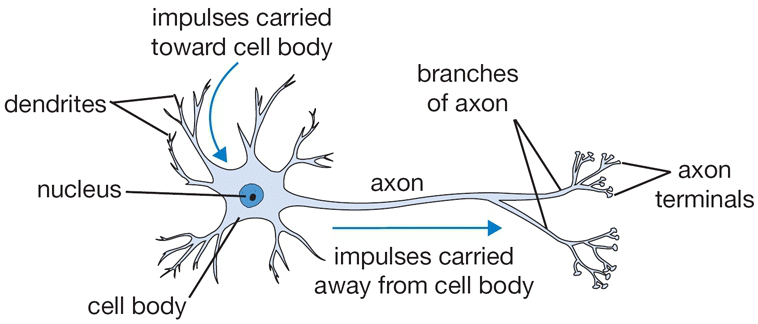

Кожен нейрон отримує вхідні сигнали від своїх дендритів
Якщо вхідні сигнали достатньо сильні, нейрон запускає вихід уздовж свого аксона, який з’єднується з дендритами інших нейронів.

## Штучний нейрон: приклад

Ми можемо імітувати цей механізм, використовуючи ідеалізований штучний нейрон.
* Дендрит $j$ отримує сигнал $x_j$; модулює мультиплікативно до $w_j \cdot x_j$.
* Тіло нейрона підсумовує модульовані входи: $\sum_{j=1}^d w_j \cdot x_j$.
* Вони надходять у функцію активації, яка створює вихідні дані.

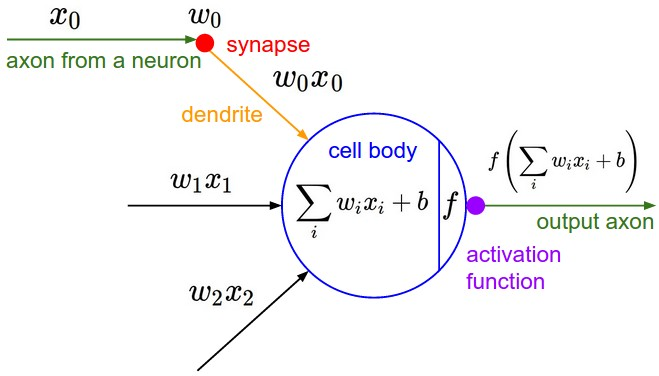

## Штучний нейрон: опис

Більш формально ми говоримо, що нейрон є моделлю $f : \mathbb{R}^d \to [0,1]$, з наступними компонентами:
* Вхідні дані $x_1,x_2,...,x_d$, позначені вектором $x$.
* Ваговий вектор $w \in \mathbb{R}^d$, який модулює вхідний сигнал $x$ як $w^\top x$.
* Функція активації $\sigma: \mathbb{R} \to \mathbb{R}$, яка обчислює вихід $\sigma(w^\top x)$ нейрона на основі суми модульованих характеристик $w^\top x$.

## Перцептрон

Якщо використовувати ступінчасту функцію як функцію активації, ми отримаємо класичну модель персептрона:

$$ f(x) =
\begin{cases}
  1 & \text{if $\theta^\top x>0$}, \\
  0 & \text{otherwise}
\end{cases}
$$

Це моделює нейрон, який спрацьовує, якщо вхідні дані достатньо великі, і не працює інакше.

Ми можемо візуалізувати функцію активації перцептрона.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

step_fn = lambda z: 1 if z > 0 else 0
plt.plot(z, [step_fn(zi) for zi in z])

## Логістична регресія як штучний нейрон

Логістична регресія є моделлю форми
$$ f(x) = \sigma(\theta^\top x) = \frac{1}{1 + \exp(-\theta^\top x)}, $$
який можна інтерпретувати як нейрон, який використовує *sigmoid* як функцію активації.

Сигмоїдна функція активації кодує ідею спрацьовування нейрона, якщо вхідні дані перевищують порогове значення, робить функцію активації «плавною».

In [ ]:
z = np.linspace(-5, 5)
sigma = 1/(1+np.exp(-z))

plt.plot(z, sigma)

## Функції активації

Є багато інших функцій активації, які можна використовувати. На практиці ці два працюють краще, ніж сигмоїдна:
* Гіперболічний тангенс (`tanh`): $\sigma(z) = \tanh(z)$
* Випрямлений лінійний елемент - Rectified linear unit (`ReLU`): $\sigma(z) = \max(0, z)$
<!-- * Leaky `ReLU`: $$\sigma(z) = \max(\alpha z, z),$$ where $\alpha$ is a small constant such as 0.1. -->

Ми можемо легко це візуалізувати.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [12, 4]

plt.subplot(121)
plt.plot(z, np.tanh(z))
plt.subplot(122)
plt.plot(z, np.maximum(z, 0))

Нейронна мережа — це орієнтований граф, у якому вузол є нейроном, який приймає як вхідні дані нейронів, які з’єднані з ним

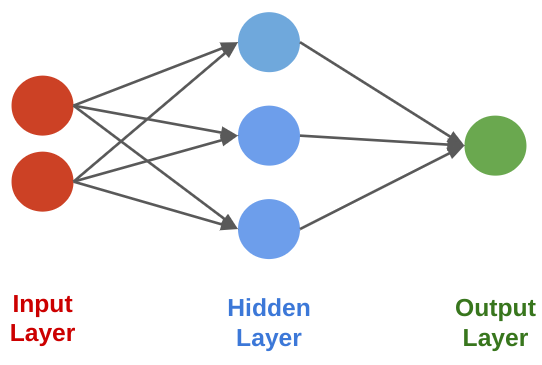


### Типи шарів нейронної мережі

Існує багато типів шарів нейронної мережі, які можуть існувати. Ось декілька:

**Вихідний (input) рівень**: зазвичай має один нейрон і спеціальну функцію активації, яка залежить від проблеми

**Вхідний (output) рівень**: зазвичай це просто вхідний вектор x.

**Прихований (hidden) шар**: будь-який шар між входом і виходом.

**Щільний (dense) шар**: шар, у якому кожен вхід підключений до кожного нейрона.

**Згортковий (convolutional) шар**: шар, на якому операція $w^\top x$ реалізує математичну згортку.

**Повторюваний (recurrent) рівень**: рівень, на якому вихід нейрона з’єднаний із входом.

<a name='1'></a>

## 1. Чому Deep Learning?

Глибоке навчання використовується для вилучення шаблонів у (великій кількості) даних. Його потенціал був помічений у складних проблемах, таких як комп'ютерній зір та природна мова.

Давайте візьмемо приклад, щоб розвинути більш інтуїтивне розуміння того, чому глибоке навчання стало таким популярним. Скажімо, як інженера, ваше місто попросило вас створити програму, яка може розпізнавати автомобіль і вантажівку, що рухаються певною дорогою. Пізніше програму можна розгорнути на менш завантаженій дорозі, щоб попереджати вантажівки, які там проїжджають, що дорога не призначена для таких типів транспортних засобів.

При звичайному програмуванні вам доведеться надати та написати всі інструкції (коди) цієї конкретної програми. Імовірність (близька до реальності) полягає в тому, що це буде важко, головним чином тому, що існують різні типи автомобілів і вантажівок, і кожен може бути унікальним по-своєму, що може ускладнити написання правил формування такої програми.

Як глибоке навчання може це вирішити? Що ж, передаючи зображення автомобілів і вантажівок моделі глибокого навчання, скажімо, згортковій нейронній мережі (детальніше про це буде пізніше), вона може вивчати основні характеристики автомобілів і вантажівок і, таким чином, зможе розпізнавати кожну окремо. Ми побачимо це на практиці в наступних заняттях.

З появою обчислювальної потужності, як платної, так і безкоштовної (Google Colab & Kaggle), наборів даних з відкритим кодом і інтелектуальних фреймворків, таких як TensorFlow і PyTorch, стало дуже можливо здійснювати глибоке навчання, навіть на особистому рівні. Десять років тому це було неможливо

Таким чином, в двох словах, глибоке навчання – це сучасна еволюція галузі штучних нейронних мереж, яка наголошує на:
* глибокі нейронні мережі
* великі неструктуровані набори даних, особливо зображення, текст і аудіо
* сучасні обчислювальні ресурси, такі як GPU

Чому глибоке навчання є потужним? Однією з причин є те, що глибокі нейронні мережі можуть дуже компактно представляти складні моделі.

Неглибокі нейронні мережі можуть представляти будь-яку функцію, але потребують дуже великих прихованих шарів.
Глибокі мережі можуть представляти дуже складні відображення з меншою кількістю параметрів.
На практиці глибокі нейронні мережі можуть вивчати дуже складні відображення, наприклад, зображення - текст, які не можуть отримати інші алгоритми

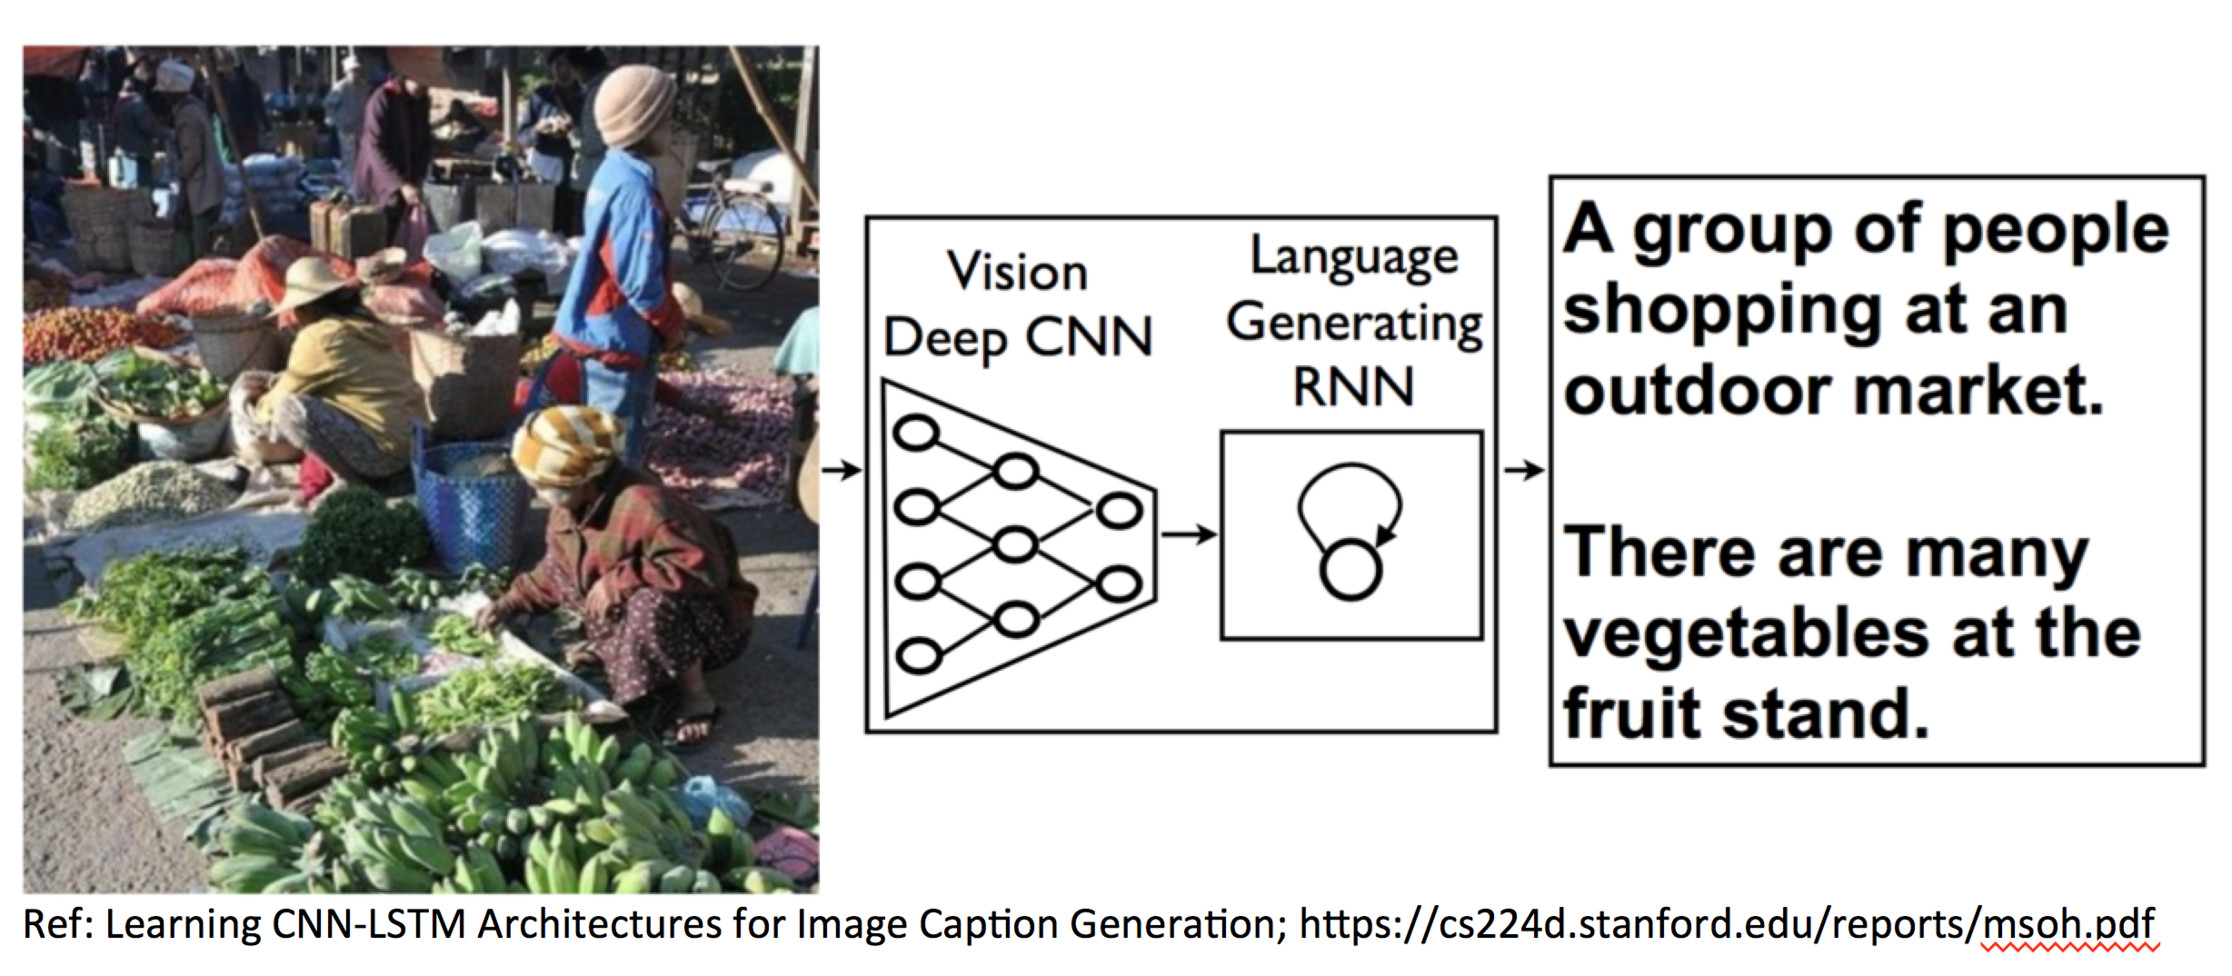

Як глибока нейронна мережа використовує свою репрезентативну силу?

Послідовні рівні можуть навчитися представляти дані на зростаючому рівні абстракції
Це також можна інтерпретувати як навчання: кожен шар відображає вхідні дані в більш абстрактний простір ознак, який вивчається з даних.
Це приклад уявлень, які глибока нейронна мережа вивчає з даних

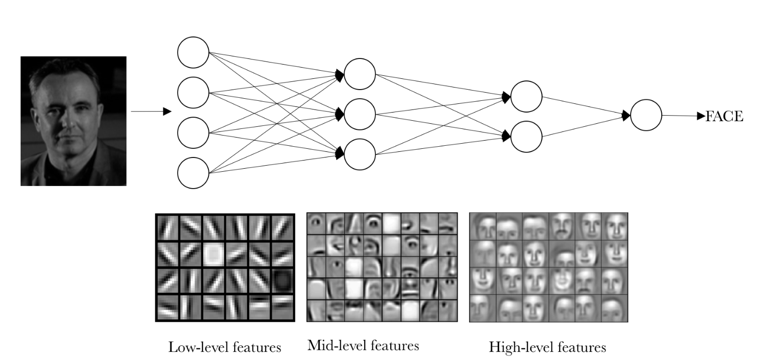

Масштабування до великих наборів даних

Моделі глибокого навчання також масштабуються до дуже великих наборів даних.

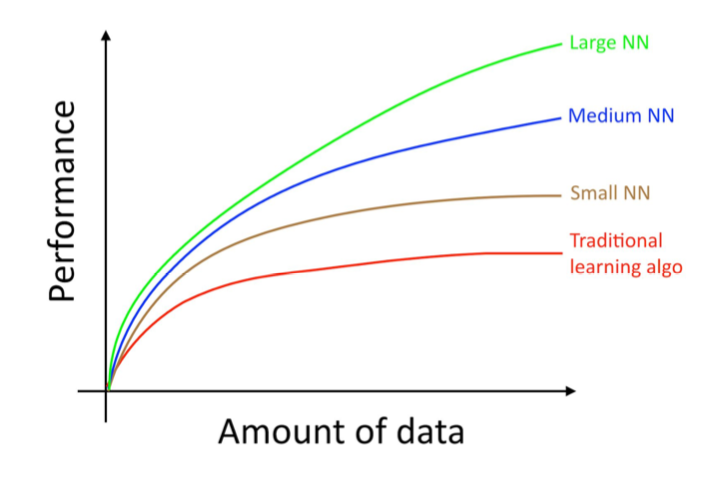

Класичні алгоритми, такі як лінійна регресія, насичуються після певного розміру набору даних. Моделі глибокого навчання постійно вдосконалюються, оскільки ми додаємо більше даних.



Обчислювальна масштабованість

Набори даних глибокого навчання виграють від великих наборів даних, оскільки вони можуть легко використовувати спеціалізоване обчислювальне обладнання.

Нейронні мережі здебільшого реалізують лінійну алгебру та виграють від апаратного прискорення.

Сьогодні вони навчаються на графічних процесорах (GPU) або навіть на більш спеціалізованому обладнанні, що призводить до прискорення на порядок.

Зв'язки з нейронаукою

Оскільки штучні нейрони створені для імітації біологічних, глибокі нейронні мережі мають міцні зв’язки з біологічними нейронними системами.

Однією з найцікавіших є мережа візуальної обробки в мозку.

Є багато доказів того, що глибокі нейронні мережі виконують обчислення, дуже схожі на обчислення зорової кори

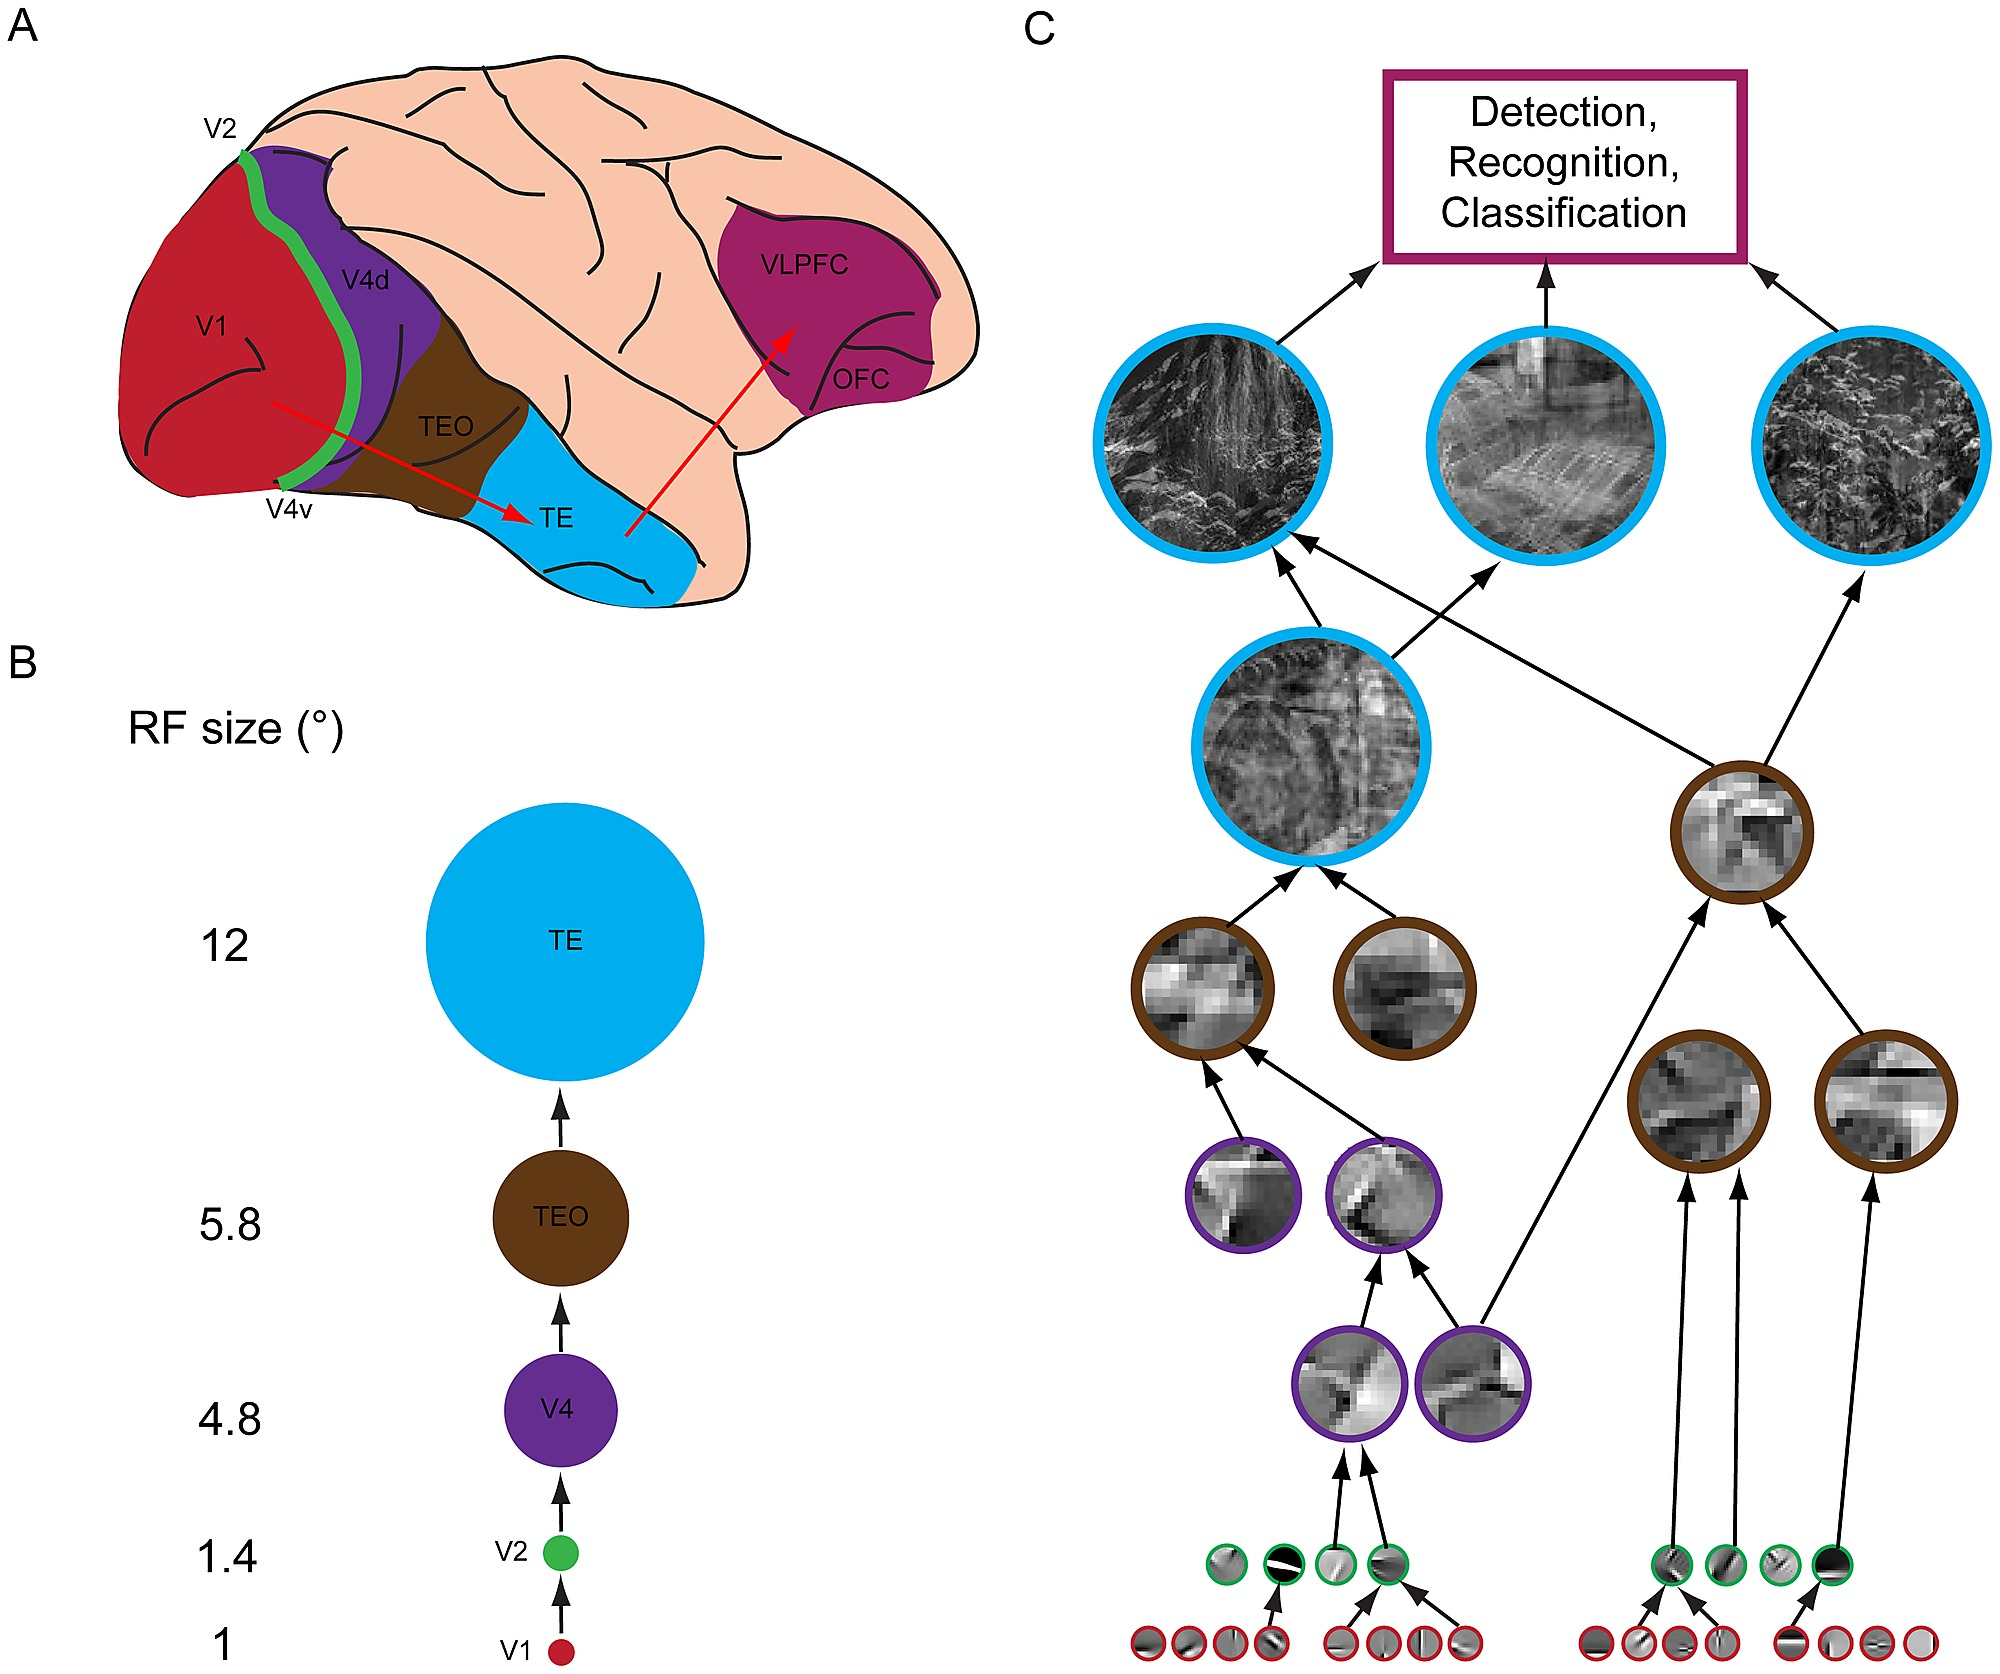

### Успіхи Deep Learning

За останнє десятиліття глибоке навчання стало справжнім проривом у машинному навчанні.

Воно значно вдосконалив такі поширені технології, як розпізнавання мовлення або машинний переклад.

Це дозволило отримати нові результати, які захопили загальну уяву.

Одним із вражаючих застосувань якісь час тому стало створення зображень.
Ці обличчя не справжні! Дивіться: https://thispersondoesnotexist.com/

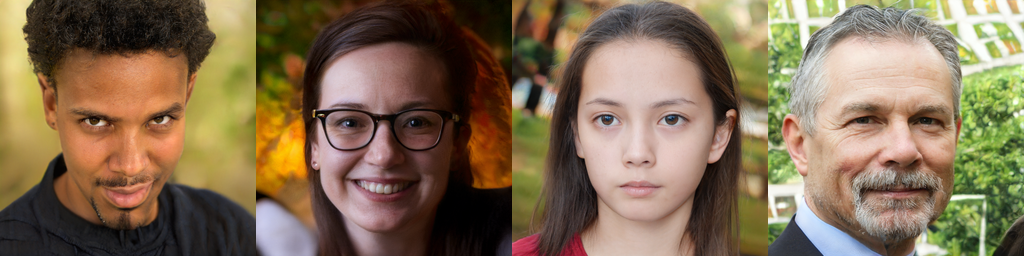

<a name='2'></a>
## 2. Нейронна мережа одного прихованого рівня

<img src="https://upload.wikimedia.org/wikipedia/commons/3/3c/Neuralnetwork.png" alt="Neuralnetwork.png"><br> Зображення: одношарова нейронна мережа, Wikimedia

Зображення вище представляє одну приховану нейронну мережу. Зазвичай будь-яка типова нейронна мережа має 3 основні рівні:

* **Вхідний рівень** який приймає вхідні дані. Вхідними даними можуть бути зображення, текст або числа, але, звісно, ​​яким би не був тип даних, вхідні дані для нейронної мережі завжди мають бути в числовому форматі.

* **Прихований шар** який знаходиться між вхідним і вихідним шарами. На цьому рівні виконується багато обчислень, про це пізніше.

* **Вихідний рівень** який дає вихід мережі. Результатом може бути числове число (переважно в задачі регресії) або ймовірність (переважно в задачі класифікації).


Зазвичай називають нейронну мережу, яка має більше одного рівня `Deep Neural Network(DNN)`. Крім того, важливо відзначити, що нейронна мережа може мати кілька вхідних рівнів, кілька прихованих шарів і кілька вихідних рівнів. Структура нейронної мережі або її розмір здебільшого залежатимуть від типу проблеми, що вирішується.

За винятком вхідного шару, ви побачите так звану функцію активації, яка застосовується до прихованих і вихідних шарів. Що таке функція активації?

<a name='3'></a>

## 3. Загальні функції активації

Функції активації використовуються для введення нелінійності в мережу.
Або простіше кажучи, ці типи математичних функцій використовуються для прийняття рішення про вихід шару. Пізніше це будемо розглядати.

Ось 3 найбільш використовувані функції активації:

* **ReLU(Rectified Linear Unit)**: це здебільшого використовується в прихованих шарах і це функція активації за замовчуванням у більшості проблем, яка добре працюватиме в більшості випадків. ReLU завжди дає позитивні результати, якщо вхідне число більше за 0, вихідним буде це число. Якщо він менший за 0, результатом буде 0. Загальна мета цього типу функції активації полягає в тому, щоб покарати від’ємні числа. ReLu має різні версії, такі як SeLU та LeakyReLU. У більшості випадків ReLU можна використовувати лише на вихідному рівні, коли проблема має тип регресії, але це також не обов’язково.


* **Sigmoid**: сигмоїдна функція дає імовірнісний вихід (число від 0 до 1). Його можна використовувати у вихідних рівнях проблеми класифікації.


* **Softmax**: Tцей тип функції також використовується в рівнях класифікації виводу, але замість того, щоб видавати імовірнісний вихід, його результатом є фактичні класи. Це будемо розглядати у наступних роботах.

<a name='4'></a>

## 4. Типи архітектур глибокого навчання

Існує 4 основних типи архітектур глибокого навчання. Вони будуть розглянуті нами на курсі.

<a name='4-1'></a>

### 4.1 Feed forward network або мережі з щільним зв’язком

Щільно з’єднані мережі складаються зі стеків шарів від входу до виходу.

Блоки (або нейрони) будь-якого рівня в цьому типі мережі з’єднані з усіма іншими елементами наступного рівня. Ось чому їх також називають повнозв’язаними шарами.

Щільно пов’язані шари зазвичай використовуються для табличних даних. Табличні дані – це такі дані, які мають табличний вигляд. Прикладом табличних даних є записи клієнтів: у вас є стовпець імен, ролей, об’єднаних даних тощо...


![Densely connected.png](https://cdn.hashnode.com/res/hashnode/image/upload/v1631359484854/ioMW08ea2.png)

Щільні шари також використовуються (у комбінації з іншими архітектурами) як останній рівень у проблемах класифікації або регресії. Правильна кількість одиниць в останньому шарі залежить від проблеми. Візьмемо приклад: якщо ви класифікуєте новини на 4 категорії, то останній шар матиме 4 одиниці. Якщо ви прогнозуєте ціну будинку з урахуванням його характеристик, останній шар матиме 1 одиницю.

Щільні мережі в основному використовуються в простих задачах. Коли мова йде про такі складні речі, як розпізнавання зображень або обробка тексту, вони зазнають невдачі, тому що не можуть утримувати просторові елементи (на зображенні) або, наприклад, не можуть вивчити послідовність у тексті. Але перш за все, чим глибшими вони стають, вони, як правило, мають багато параметрів, що може призвести до великої мережі/складних обчислень.

<a name='4-2'></a>

### 4.2 Згорткові нейронні мережі

CNN (Convolutional Neural Network), також відомі як Convnets, широко відомі як архітектури нейронних мереж для завдань комп’ютерного зору, таких як розпізнавання зображень і виявлення об’єктів, але їх також можна використовувати в інших завданнях, таких як обробка текстів і часових рядів.

Convnets зазвичай складаються з згортки, шарів об’єднання та повністю зв’язаних шарів у кінці. Згорткові шари використовуються для вилучення просторових особливостей у зображеннях, а шари об’єднання використовуються для стиснення отриманих карт функцій із шарів згортки. І повністю пов’язані шари для цілей класифікації.

![on-IOL-iG.png-2.webp](https://cdn.hashnode.com/res/hashnode/image/upload/v1630788206761/KF4gj3zPD.webp)

Convnets мають 3 виміри. Найпопулярнішим є Conv2D, який використовується в зображеннях і відео, розділених на кадри. Conv1D використовується в послідовних даних, таких як тексти, часові ряди та звуки. Популярна звукова архітектура під назвою [WaveNet](https://deepmind.com/blog/article/wavenet-generative-model-raw-audio) складається з 10 складених 1D Convnets.

Conv3D використовується у відео та об’ємних зображеннях CT scans.

<a name='4-3'></a>

### 4.3 Рекурентні нейронні мережі (RNNs)


Стандартна мережа прямого зв’язку або з щільним зв’язком відображає вхідні дані на вихідні. Recurrent neural networks (RNN) виходять за рамки цього. Вони можуть підтримувати повторення даних на кожному кроці часу.


![TF RNN.png](https://cdn.hashnode.com/res/hashnode/image/upload/v1630789332991/7kzTaiwxp.png)

Завдяки своїй здатності зберігати повторюваність інформації, RNN зазвичай використовуються в послідовних даних, таких як тексти та часові ряди.

Базові комірки RNN неефективні при обробці великих послідовностей через проблему з короткою пам’яттю. Вони також страждають від [vanishing gradients](https://www.youtube.com/watch?v=qhXZsFVxGKo).

Варіант RNN, який здатний обробляти довгі послідовності, називається довгою короткочасною пам’яттю (LSTM). LSTM також має можливість обробляти послідовності змінної довжини.

Особлива конструктивна відмінність комірки LSTM полягає в тому, що вона має шлюз, який є основою, чому вона може контролювати потік інформації протягом багатьох часових кроків.

Коротше кажучи, LSTM використовує шлюзи для керування потоком інформації від поточного кроку часу до наступного кроку в наступні 4 способи:

  * Вхідний вентиль розпізнає вхідну послідовність.
  * Forget gate позбавляється від усієї нерелевантної інформації, що міститься у вхідній послідовності, і зберігає відповідну інформацію в довготривалій пам’яті.
  * Оновлення комірки LTSM оновлює значення стану комірки.
  * Вихідний вентиль контролює інформацію, яку потрібно надіслати на наступний часовий крок.

![Screen Shot 2021-09-01 at 09.22.56.png](https://cdn.hashnode.com/res/hashnode/image/upload/v1630789390006/avzF2LKrK.png)

*Архітектура LSTM, [Intro to Deep Learning MIT](https://www.youtube.com/watch?v=BUNl0To1IVw&list=PLtBw6njQRU-rwp5__7C0oIVt26ZgjG9NI&index=5)*

Здатність LSTM обробляти довготривалі послідовності робить її придатною архітектурою нейронної мережі для різноманітних послідовних завдань, таких як класифікація тексту, аналіз настроїв, розпізнавання мови, створення підписів до зображень, машинний переклад.

Ще одна рекурентна нейронна мережа, яку ви побачите, це [Gate Recurrent Unit(GRU)](https://arxiv.org/pdf/1412.3555.pdf). GRU це спрощена версія LSTM, і її навчання дешевше.


<a name='4-4'></a>

### 4.4 Transformers


Хоча рекурентні нейронні мережі все ще використовуються для послідовного моделювання, вони мають проблеми з короткочасною пам’яттю, коли використовуються для довгих послідовностей, і вони дорогі з точки зору обчислень. Нездатність RNN обробляти довгі послідовності та дороговизна є двома головними мотивами transformers.

Transformers — одне з останніх новаторських досліджень у спільноті природних мов. Вони дуже ґрунтуються на механізмах уваги, які вивчають зв’язки між словами в реченні та звертають увагу на відповідні слова.

Однією з найбільш помітних особливостей transformers є те, що вони не використовують жодних рекурентних або згорткових шарів. Це лише механізми привернення уваги та інші стандартні шари, такі як шар вбудовування, щільний шар і шари нормалізації.

Вони зазвичай використовуються в таких мовних завданнях, як класифікація тексту, відповіді на запитання та машинний переклад.

Були проведені [дослідження](https://arxiv.org/pdf/2101.01169.pdf), які показують, що їх також можна використовувати для завдань комп’ютерного зору, таких як класифікація зображень, виявлення об’єктів, сегментація зображень і створення підписів до зображень із [visual attention](https://arxiv.org/pdf/1502.03044.pdf).

Щоб дізнатися більше про transformer, можете подивиться [цей документ](https://arxiv.org/pdf/1706.03762.pdf).


![Screen Shot 2021-09-04 at 23.16.48.png](https://cdn.hashnode.com/res/hashnode/image/upload/v1630790223290/99Ltf-fAy.png)

*Архітектура Transformers (https://arxiv.org/pdf/1706.03762.pdf)*




Нижче наведено короткий виклад загальних архітектур нейронних мереж.

![Deep Learning Architectures.png](https://cdn.hashnode.com/res/hashnode/image/upload/v1631774267019/jzEyGcRBWM.png)

<a name='5'></a>

## 5. Проблеми в навчанні нейронних мереж

Навчання нейронних мереж є великою проблемою, і це ще область досліджень. Наприклад, як вибрати правильну архітектуру? Хоча тип даних може розповісти про архітектуру, яка повинна з’явитися спочатку, це не тривіальне питання. Візьмемо приклад, ми знаємо CNN як алгоритм першого зображення, трохи його використовували в деяких завданнях обробки природної мови та часових рядів, і він може добре працювати.

Крім того, моделі глибокого навчання мають багато гіперпараметрів. Гіперпараметри включають такі речі, як кількість шарів, кількість нейронів, швидкість навчання, функції активації та оптимізатори (оптимізатори використовуються для зменшення втрат під час навчання).

Усі ці можливі варіанти ускладнюють навчання нейронних мереж. Хоча існують деякі методи, які можуть зменшити кількість вибору, який необхідно зробити, [наприклад, перенесення навчання, яке спонукає до повторного використання попередньо навчених моделей](https://jeande.tech/transfer-learning-explained), навчити цей тип моделей непросто.

Якщо ви хочете дізнатися більше про навчання нейронних мереж, ось чудовий (але складний) матеріал про це: [Чому глибокі нейронні мережі важко навчити?](http://neuralnetworksanddeeplearning.com/chap5.html).

#### Якщо бажаєте, то попрацюйте з цією грою і спробуйте побачити, як такі речі, як функції активації, вхідні дані, швидкість навчання... впливають на навчання нейронної мережі [***Ось вона***](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.93635&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false).

<a name='0'></a>
# Знайомство з TensorFlow для глибокого навчання

1. Що таке TensorFlow?
2. API моделі TensorFlow
  
  2.1 Послідовний API
  
  2.2 Функціональний API
  
  2.3 API підкласів моделі
3. Короткий огляд екосистеми TensorFlow
  
  3.1 Інструменти
  
  3.2 Моделі та набори даних
  
  3.3 Розгортання моделі
4. Основи тензорів

  4.1 Вступ до тензорів
  
  4.2 Створення тензора за допомогою tf.constant()
  
  4.3 Створення тензора за допомогою tf.variable()
  
  4.4 Створення тензора з існуючих функцій
  
  4.5 Вибір даних у тензорі
  
  4.6 Виконання операцій над тензорами
  
  4.7 Маніпулювання формою тензора

<a name='1'></a>

## 1. Що таке TensorFlow?

TensorFlow — це наскрізна платформа з відкритим кодом, яка використовується для створення моделей машинного навчання. Ви можете готувати дані, будувати моделі, діагностувати, покращувати та розгортати їх.

TensorFlow використовує [Keras](https://keras.io) у своєму сервері. Keras — це чудово розроблений API для створення моделей глибокого навчання в таких популярних сферах, як комп’ютерне бачення та обробка природної мови.

У TensorFlow є сильна спільнота користувачів, навчальних ресурсів і цілого ряду технічної підтримки. Він не лише працює в більшості програм Google, таких як YouTube, Карти та Google Фото, але також широко використовується в стартапах та інших великих технічних компаніях. Якщо ви хочете знати, хто використовує TensorFlow, [ось тут!](https://www.tensorflow.org/about/case-studies).  

<a name='2'></a>

## 2. API моделі TensorFlow

Оскільки TensorFlow підходить для різноманітних завдань, існує 3 способи створення моделей глибокого навчання

 <a name='2-1'></a>
 ### 2.1 Послідовний API

Це найпростіший варіант побудови моделі. Під час створення моделі ви починаєте від входу до виходу, ніяк інакше. Цей API підходить для завдань, які не вимагають кількох входів і виходів або пропуску підключень.

Послідовний API може бути хорошим API для таких речей, як класифікація зображень або завдання регресії. Для таких речей, як виявлення та сегментація об’єктів, нам потрібен інший API, який є функціональним API.

Нижче показано, як виглядає послідовна модель.

```
# Building a sequential model

from tensorflow import keras


model = keras.models.Sequential([
        
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
        
])
    
```

<a name='2-2'></a>
### Функціональний API

Цей тип API дозволяє легко створювати моделі, які можуть приймати кілька вводів/виходів або пропускати підключення.

Він добре підходить для просунутих речей, таких як виявлення об’єктів і сегментація. У виявленні об’єктів є дві основні речі.

Один — це розпізнавання об’єкта (класифікація), а інший — локалізація об’єкта (регресія: передбачення координат обмежувальних рамок).


![kites_detections_output.jpg](https://cdn.hashnode.com/res/hashnode/image/upload/v1616839653654/-NiIL9N3v.jpeg)
*Ви не можете побудувати модель виявлення об’єктів за допомогою послідовного API, замість цього можна створити функціональний API! [Джерело](https://github.com/tensorflow/models/tree/master/research/object_detection).*

Нижче показано, як виглядає функціональна модель.

```
# Building a same model in Functional API

from tensorflow import keras

inputs = keras.Input()
x = keras.layers.Dense(16, activation='relu')(inputs)
x = keras.layers.Dense(32, activation='relu')(x)
output = keras.layers.Dense(1, activation='sigmoid')(x)
    
model = keras.Model(inputs, output)
```

<a name='2-3'></a>

### Модель SubClassing

SubClassing API призначений для створення користувальницьких моделей і повного контролю над кожним кроком створення та навчання моделі.

У більшості випадків послідовний і функціональний API буде всім, що вам знадобиться для створення майже будь-чого.

Нижче показано, як виглядає модель підкласу

```
# Building a same custom model

from tensorflow import keras

class MLP(keras.Model):

  def __init__(self, **kwargs):
    super(MLP, self).__init__(**kwargs)
    self.dense_1 = keras.layers.Dense(16, activation='relu')
    self.dense_2 = keras.layers.Dense(32, activation='relu')
    self.dense_3 = keras.layers.Dense(1, activation='sigmoid')

  def call(self, inputs):
    x = self.dense_1(inputs)
    x = self_dense_2(x)
    x = self_dense_3(x)
    
    return x

# Instantiate the model

mlp = MLP()
```

<a name='3'></a>

## 3. Короткий огляд екосистеми TensorFlow

Окрім спільноти, одна з моїх улюблених речей у TensorFlow — це ціла екосистема інструментів і ресурсів. Нижче наведено список інструментів, бібліотек і ресурсів, створених для спрощення.

<a name='3-1'></a>

### Інструменти


#### 1. Colaboratory

[Colaboratory](https://colab.research.google.com/notebooks/intro.ipynb) це безкоштовна веб-версія jupyter notebook, яка не потребує налаштування. Ви можете імпортувати майже будь-яку бібліотеку, не встановлюючи її (зараз ми тут і є).

#### 2. TensorBoard

[TensorBoard](https://tensorboard.dev/) надає інженерам і науковцям можливості візуалізації та налагодження їхніх моделей машинного навчання.

За допомогою TensorBoard ви можете:

   * Відстежуйте та візуалізуйте показники втрат і точності
   * Перегляд вагових коефіцієнтів, зміщень та інших параметрів у форматі графіків, як-от гістограма або лінійний графік
   * Відображати зображення, аудіо та текстові дані
   * Подивіться, які гіперпараметри можуть підійти для зближення моделі
   

![Tensorboard.png](https://cdn.hashnode.com/res/hashnode/image/upload/v1616575702847/t9hohDbAY.png)

#### 3. What If Tool(WIT)

Що, якби вам потрібен візуальний спосіб зрозуміти ваші дані та модель у вашому середовищі? [WIT](https://pair-code.github.io/what-if-tool/get-started/) створений саме для цієї мети. Це може допомогти вам зрозуміти ваш набір даних і результат вашої моделі.



<a name='3-2'></a>

### Моделі та набори даних



#### 1. TensorFlow Hub

[TensorFlow Hub](https://tfhub.dev/) це набір готових до використання моделей у різноманітних завданнях, від розпізнавання зображень, виявлення об’єктів, сегментації зображень, розпізнавання звуку, класифікації тексту тощо

#### 2. Model Garden

Model Garden є [офіційним репозиторієм GitHub моделей TensorFlow](https://github.com/tensorflow/models/tree/master/official), створених за допомогою API високого рівня. Доступні моделі комп’ютерного бачення, обробки природної мови та рекомендація.

#### 3. TensorFlow Datasets (TFDS)

[TFDS](https://www.tensorflow.org/tfds) містить набори даних різних типів, від зображень, текстів, відео до звуків... Ми будемо використовувати багато наборів даних TFDS у нашому курсі глибокого навчання.




**************

Є так багато інструментів і функцій, які надає TensorFlow. Наскільки зможемо, ми намагатимемося використовувати ці інструменти.

Це був короткий огляд екосистеми TensorFlow. Якщо ви хочете дізнатися більше, перейдіть на  [веб-сайт tensorflow](https://www.tensorflow.org/resources/libraries-extensions)


<a name='3-3'></a>
### Розгортання моделей



#### 1. TensorFlow Extended (TFX)

[TFX](https://www.tensorflow.org/tfx/) це наскрізна платформа для створення конвеєрів машинного навчання. За допомогою TFX ви можете готувати дані, тренувати моделі, перевіряти їх і розгортати у виробничих середовищах.

#### 2. TensorFlow.js

[TensorFlow.js](https://www.tensorflow.org/js/) полегшує навчання та розгортання моделі у веб-браузерах.

#### 3. TensorFlow Lite

[TF Lite](https://www.tensorflow.org/lite/) дає змогу навчати, розгортати та оптимізувати моделі в мобільних пристроях і мікроконтролерах.

<a name='4'></a>

## 4. Основи тензорів

<a name='4-1'></a>
### 4.1 Вступ до тензорів

Тензор — це багатовимірний масив даних одного типу. Тензор може бути скаляром (одним числом), вектором або матрицею.

Якщо ви використовували NumPy, тензори схожі на масиви NumPy, за винятком того, що тензори мають підтримку графічного процесора (GPU).

Типовий тензор має таку інформацію:

* **Shape**: довжина або кількість елементів кожного розміру/осей тензора.
* **Rank**: кількість вимірів/осей у тензорі. Скалярний тензор (одне число) має ранг 0, вектор має ранг 1 (вектор є одновимірним), а матриця має ранг 2 (або 2D).
* **Axis/Dimension**: це окремий розмір тензора
* **Size**: це загальна кількість елементів у тензорі.

Але навіщо масиви Tensor/NumPy?

Майже всі типи даних можна представити у вигляді масиву чисел. Візьмемо приклад:

* Зображення можна представити у вигляді масиву пікселів.
* Будь-які текстові дані можна перетворити на масив чисел (або токенів, що представляють слова)
* Відео (складене з послідовності зображень) можна представити у вигляді масиву чисел.

Можливість конвертувати ці необроблені дані в тензори/масиви полегшує їх попередню обробку під час виконання звичайних числових обчислень або коли це дані, які ми готуємося передати в модель машинного навчання. Візьмемо простий приклад: ми не можемо передати необроблений текст моделі машинного навчання. Цей текст потрібно перетворити на числа.

Це базове введення в bensors. Щоб отримати додаткові відомості про тензори, ознайомтеся зі [вступом до TensorFlow](https://www.tensorflow.org/guide/tensor), або на цій [сторінці wikipedia ](https://en.wikipedia.org/wiki/Tensor).


<a name='4-2'></a>

### 4. 2 Створення тензора за допомогою tf.constant()

Тензор може бути скаляром, вектором або матрицею. Давайте використаємо `tf.constant()` для створення цих типів тензорів.

Тензор, створений за допомогою `tf.constant()` є незмінним.

In [ ]:
# спочатку імпортуємо tensorflow як tf
# також імпортуємо numpy як np
# якщо ви використовуєте Colab, їх не потрібно встановлювати

import tensorflow as tf
import numpy as np

In [ ]:
# Створення скалярного тензора
# Ви можете вказати dtype, але TF виявить його, якщо не вказати

scalar_tensor = tf.constant(10)

In [ ]:
# Відображення створеного тензора

print(scalar_tensor)

In [ ]:
# Ми також можемо створити вектор або тензор рангу 1
# Простіше кажучи, вектор є одновимірним
# Ми можемо створити його зі списку значень

vect_tensor = tf.constant([1.0,2.0,3.0,4.0,5.0,6.0])

In [ ]:
print(vect_tensor)

Було створено вектор одновимірних значень. Як ви можете бачити, тип даних є `float32` тому, що значення були плаваючими. TensorFlow виявляє це автоматично зі значень, якщо тип даних не вказано.

Давайте тепер створимо тензор з рангом 2 або двома вимірами. Це фактично матриця.

In [ ]:
mat_tensor = tf.constant([[2,4],
                         [6,8],
                         [10,12]], dtype=tf.int32)

In [ ]:
print(mat_tensor)

Якщо ви бачите на зображеному вище тензорі, це `(3,2)` означає, що наш тензор має 3 рядки та 2 стовпці.

Ви також можете перевірити кількість вимірів або осей тензора за допомогою `tensor_name.ndim`

In [ ]:
scalar_tensor.ndim

Скалярний тензор не має розмірності. Це лише одне значення. Але якщо ми зробимо те саме для вектора чи матриці, ви побачите щось інше.

In [ ]:
# Вектор має 1 вимір

vect_tensor.ndim

In [ ]:
# Матриця має 2D або більше вимірів

mat_tensor.ndim

Як і масив NumPy, тензор може мати багато вимірів. Давайте створимо тензор із 3 вимірами.

In [ ]:
tensor_3d = tf.constant([
                         [[1,2,3,4,5],
                         [6,7,8,9,8]],
                         [[1,3,5,7,9],
                         [2,4,6,8,1]],
                         [[1,2,3,5,4],
                         [3,4,5,6,7]], ])

print(tensor_3d)

In [ ]:
tensor_3d.ndim

Тензор можна перетворити на масив NumPy за допомогою виклику `tensor_name.numpy` або `np.array(tensor_name)`.

TensorFlow добре поєднується з NumPy. І якщо це ще не зроблено, TensorFlow нещодавно опублікував повідомлення про те, що вони працюють над інтеграцією всього NumPy у TensorFlow.

In [ ]:
# Перетворення тензора в масив NumPy

n_array = tensor_3d.numpy()

n_array

In [ ]:
# Використання np.array(tensor_name)

np.array(tensor_3d)

<a name='4-3'></a>

### 4. 3 Створення тензора за допомогою tf.Variable()

Тензор, створений за допомогою `tf.constant()` є незмінним, його не можна змінити. Такого роду тензори не можна використовувати як ваги в нейронних мережах, тому що їх потрібно змінити/оновити, наприклад, у зворотному поширенні.

За допомогою `tf.Variable()`, ми можемо створювати тензори, які можуть бути змінними і, таким чином, використовуватися для таких речей, як оновлення ваг нейронних мереж, як зазначено вище.

Створення змінного тензора таке ж просте, як і перше.

In [ ]:
var_tensor = tf.Variable([
                         [[1,2,3,4,5],
                         [6,7,8,9,8]],
                         [[1,3,5,7,9],
                         [2,4,6,8,1]],
                         [[1,2,3,5,4],
                         [3,4,5,6,7]], ])

print(var_tensor)

Його також можна перетворити на масив NumPy, як і тензори, створені за допомогою `tf.constant()`

In [ ]:
# Перетворення тензора змінної в масив NumPy

var_tensor.numpy()

<a name='4-4'></a>

### 4.4 Створення тензора з існуючих функцій

Є деякі типи рівномірних тензорів, які ви не хотіли б створювати з нуля, хоча насправді вони вже створені.

Візьмемо приклад тензора одиниць, нулів і випадкових тензорів. Давайте створимо їх.

In [ ]:
# Створення тензора 1

ones_tensor = tf.ones([4,4])

print(ones_tensor)

In [ ]:
# Створення тензора 1

ones_tensor_1 = tf.ones([1,10])

print(ones_tensor_1)

In [ ]:
# Створення тензора нулів

tensor_0 = tf.zeros([3,3])
print(tensor_0)

Ми також можемо створити тензор із випадковими значеннями. Під час ініціалізації вагових коефіцієнтів у нейронних мережах ваги приймають випадкові значення.

Ви можете подумати, чому б нам зараз не будувати нейронні мережі, і я вас розумію. Розуміння основ тензорів і особливо робота з TensorFlow корисно, коли справа доходить до створення власних шарів нейронної мережі, функцій втрат або оптимізаторів.

Пізніші лабораторії не стосуватимуться користувальницьких шарів/втрат/оптимізаторів, це лише вступ, тож це може слугувати довідником, коли ви захочете зробити крок назад у основу API високого рівня TensorFlow.

In [ ]:
# Створення тензора з випадковими значеннями

# Спочатку ми повинні створити об'єкт-генератор

rand_tensor = tf.random.Generator.from_seed(3)

rand_tensor = rand_tensor.normal(shape=[3,3])
print(rand_tensor)

Зміна початкового номера в `tf.random.Generator.from_seed(3)` призведе до зміни значень, які повертає функція random.

Ми також можемо перетасувати існуючий тензор, створений за допомогою `tf.constant()` або `tf.Variable()`.

In [ ]:
# Створіть типовий тензор

example_tensor = tf.constant([[1,3],
                             [3,4],
                             [4,5]])

print(example_tensor)

In [ ]:
def shuffle_tensor(tensor):

  """
  Взяти тензор як вхідні дані та повернути перетасований тензор
  """
  # Перетасувати порядок створеного тензора

  tensor_shuffled = tf.random.shuffle(tensor)

  return print(tensor_shuffled)

In [ ]:
shuffle_tensor(example_tensor)

Якщо ви повторите наведену вище комірку більше одного разу, ви отримаєте різні порядки тензора



In [ ]:
shuffle_tensor(example_tensor)

Щоб запобігти цьому, ми можемо використовувати `tf.random.set_seed(seed_number)` завжди отримувати той самий порядок/значення.

In [ ]:
# Встановить seed

tf.random.set_seed(42)

shuffle_tensor(example_tensor)

Кожного разу, коли ви можете запустити  `shuffle_tensor` функцію з тим самим початковим числом, ви отримаєте той самий порядок.

YВи можете дізнатися більше про генерацію випадкових чисел [тут](https://www.tensorflow.org/guide/random_numbers#the_tfrandomgenerator_class).

<a name='4-5'></a>

### 4.5 Вибір даних у Tensor

Ми також можемо вибрати значення будь-якого тензора, як одновимірного, так і багатовимірного тензора.

In [ ]:
# Давайте створимо тензор

tensor_1d = tf.constant([1,2,3,4,5,6,7])

Давайте виберемо кілька значень у створеному вище тензорі.

In [ ]:
print('The first value:', tensor_1d[0].numpy())
print('The second value:', tensor_1d[2].numpy())
print('From the 3 to 5th values:', tensor_1d[3:5].numpy())
print('From the 3 to last value:', tensor_1d[3:].numpy())
print('The last value:', tensor_1d[-1].numpy())
print('Select value before the last value:', tensor_1d[-2].numpy())
print('Select all tensor values:', tensor_1d[:].numpy())

Вибір/індексація даних у тензорі схожа на індексацію списку Python, а також NumPy.

Давайте також виберемо дані в 2D-тензорі.

In [ ]:
tensor_2d = tf.constant([[1,3],
                          [3,4],
                          [4,5]])

In [ ]:
print('The first row:', tensor_2d[0,:].numpy())
print('The second column:', tensor_2d[:,1].numpy())
print('The last low:', tensor_2d[-1,:].numpy())
print('The first value in the last row:', tensor_2d[-1,0].numpy())
print('The last value in the last column:', tensor_2d[-1,-1].numpy())

<a name='4-6'></a>

### 4.6 Виконання операцій над тензорами

Над тензором можна виконувати всі числові операції. Давайте подивимося кілька з них

In [ ]:
# Створення прикладів тензорів

tensor_1 = tf.constant([1,2,3])
tensor_2 = tf.constant([4,5,6])

In [ ]:
# Додавання скалярного значення до тензора

print(tensor_1 + 4)

In [ ]:
# Додавання двох тензорів

print(tensor_1 + tensor_2)

In [ ]:
# Можна також додати за допомогою tf.add() або tf.math.add()

print(tf.add(tensor_1, tensor_2))

In [ ]:
# множення тензорів за допомогою tf.multiply()

print(tf.multiply(tensor_1, tensor_2))

Ви можете дізнатися більше в офіційних документах про [`tf.math()`](https://www.tensorflow.org/api_docs/python/tf/math) Над тензорами можна виконувати майже всі математичні операції.


<a name='4-7'></a>

### 4.7 Маніпулювання формою тензора

Бувають випадки, коли вам захочеться змінити форму тензора. Ось як це зробити

In [ ]:
print(example_tensor)

Давайте переформулюємо наведений вище тензор у `(2,3)`.

In [ ]:
tens_reshaped = tf.reshape(example_tensor, [2,3])

In [ ]:
print(tens_reshaped)

In [ ]:
# Також до (6,1)

print(tf.reshape(example_tensor, [6,1]))

In [ ]:
# Ви також можете сформувати тензор у список

print(example_tensor.shape.as_list())

In [ ]:
# Ви також можете звести тензор

print(tf.reshape(example_tensor, [-1]))

Існують правила зміни форми тензора. Нова форма має бути резонансною. Візьмемо приклад нижче, це створить помилку, тому що ви не можете змінити форму `example_tensor into (5,5).`

In [ ]:
# Запуск клітинки нижче призведе до помилки

# print(tf.reshape(example_tensor, [5,5]))

*******************

Ось і все для ознайомлення з TensorFlow та основами тензорів. 'TensorFlow API revolves around tensors'`(цитата Aurelion Geron)`, і тому ми не відразу приступили до великих речей із високорівневим API TF, не дослідивши, що робить їх можливими.

<a name='0'></a>
# Нейронні мережі для регресії з TensorFlow

1. Введення в регресію з TensorFlow
2. Почніть з простого: побудуйте пряму лінію

  2.1 Збір даних

  2.2 Перегляд даних
  
  2.3 Підготовка даних для моделі
  
  2.4 Створення, компіляція та навчання моделі
  
  2.5 Оцінка моделі
  
  2.6 Удосконалення моделі
3. Going Beyond: набір даних реального світу

  3.1 Збір даних
  
  3.2 Перегляд даних
  
  3.3 Підготовка даних для моделі
  
  3.4 Створення, компіляція та навчання моделі
  
  3.5 Оцінка моделі
  
  3.6 Покращення моделі
  
  3.7 Збереження моделі
  
  3.8 Заключні примітки


<a name='1'></a>
## Вступ до регресії з TensorFlow

Ми знаємо нейронні мережі для створення місячних знімків, але їх також можна використовувати для задач регресії.

У завданнях/проблемах регресії ми зацікавлені в передбаченні одного чи кількох неперервних чисел.

Розглянемо приклад прогнозування ціни на житло. Нам можуть бути дані такі властивості/особливості будинку, як розмір, регіон і кількість спалень, щоб передбачити ціну такого будинку. Цей приклад є передбаченням одного числа, яке також називають `univariate regression`.

Інший приклад з’являється у виявленні об’єктів (розпізнавання та локалізація зображення). Щоб локалізувати об'єкт з обмежувальною рамкою, вам потрібно знайти координати центру об'єкта та обмежувальної рамки. Прогнозування цих координат є прикладом прогнозування кількох значень одночасно. Його зазвичай називають `multivariate regression`.

Будь-яка типова архітектура регресійної нейронної мережі матиме загальні значення або діапазони значень `hyperparameters` (гіперпараметри — це всі параметри, які ви як інженер маєте встановити, наприклад швидкість навчання, кількість шарів тощо). Давайте обговоримо їх.


#### **Вхідні, приховані та вихідні шари**

Вхідний рівень зазвичай має нейрони (або одиниці), еквівалентні кількості вхідних функцій. Наприклад, якщо наш набір даних про будинок містить 10 змінних, 9 вхідних навчальних функцій, 1 цільову функцію (ціна будинку), тоді вхідних нейронів буде 9.

Кількість прихованих шарів залежить від проблеми та розміру набору даних, але зазвичай це буде від 1 до 5. Те саме стосується кількості нейронів у кожному прихованому шарі, це залежатиме від проблеми та розміру набору даних, але загалом нейронів може бути від 10 до 100.

Кількість нейронів у вихідному шарі залежатиме від проблеми. Якщо ви передбачаєте одне число, воно буде 1. Якщо ви передбачаєте координати центру об’єкта та обмежувальної рамки під час виявлення об’єкта, це буде 4 (оскільки є 4 координати, 2 для центру об’єкта, 2 для висоти/ ширина box)


#### **Функція активації**

Вибір функції активації залежить від проблеми, але в більшості випадків reluвона добре працюватиме на прихованих шарах.

Функція активації на вихідному рівні дуже специфічна щодо мети проблеми. На відміну від нейронних мережевих класифікаторів, які зазвичай використовують [`sigmoid`](https://en.wikipedia.org/wiki/Sigmoid_function) або [`softmax`](https://en.wikipedia.org/wiki/Softmax_function), регресор не потребує активації, оскільки вам потрібні вихідні значення такими, якими вони є. З огляду на це, ви можете запобігти від’ємним значенням у вихідному шарі. У такому випадку ви можете використовувати [`ReLU`](https://en.wikipedia.org/wiki/Rectifier_(neural_networks)).


#### Функція втрати навчання

Функція втрат, яка використовується в регресії, зазвичай дорівнює [`Mean Squared Error(MSE)`](https://en.wikipedia.org/wiki/Mean_squared_error). Якщо ви знаєте, що ваш набір даних містить викиди, ви можете використовувати [`Mean Absolute Error (MAE)`](https://en.wikipedia.org/wiki/Mean_absolute_error). MAE потенційно можна використовувати для прогнозування часових рядів, оскільки цей тип даних має тенденцію мати викиди.

Ще одна функція втрат, яка часто використовується, якщо [втрати Хубера](https://www.tensorflow.org/api_docs/python/tf/keras/losses/huber). Це комбінація як MSE, так і MAE.

#### Оптимізатор

Хорошим емпіричним правилом при виборі оптимізатора є починати з [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam). Є й інші оптимізатори, які ви можете спробувати, наприклад SGD (Stockastic Gradient Descent), RMSProp, Nadam тощо... Дізнайтеся більше про них на [сторінці документації оптимізатора TensorFlow](https://www.tensorflow.org/api_docs/python/tf/optimizers).

Нижче наведено короткий виклад найкращих практик гіперпараметрів у регресорах нейронних мереж.



| **Гіперпараметр** | **Типове значення** |
| --- | --- |
| Нейрони на вхідному шарі | 1 нейрон на функцію |
| Кількість прихованих шарів | залежно від проблеми, починайте від 1 до 10 |
| Нейронів на прихований шар | залежно від проблеми, зазвичай від 10 до 100 |
| Нейрони на вихідному шарі | залежать від бажаного результату, 1 для одновимірної регресії |
| Активація в прихованих шарах | Relu або його варіанти (LeakyReLU, SeLU)|
| Активація на вихідному рівні |У більшості випадків жодного|
| Функція втрат | MSE або MAE |
| Оптимізатор | SGD, Adam, RMSProp |

*Таблиця: Типові значення гіперпараметрів у регресорах нейронної мережі*

У нейронних мережах існує багато гіперпараметрів, і пошук найкращих значень кожного може бути надзвичайно складним.

Під час вибору гіперпараметрів рекомендується використовувати інструменти налаштування гіперпараметрів, такі як [Keras Tuner](https://keras.io/keras_tuner/) щоб знайти найкращі гіперпараметри, коли це можливо. Майже неможливо припустити, що задане значення гіперпараметра спочатку працюватиме добре. Зазвичай нам доводиться експериментувати з різними значеннями, і хороший інструмент може допомогти вам зробити це швидко.

Давайте застосуємо все вищесказане на практиці, починаючи з простого, а потім роблячи наступний крок у реальний набір даних.

<a name='2'></a>

## 2. Почніть з простого: побудуйте пряму лінію

Однією з найпростіших речей, які ми можемо змоделювати, є, можливо, лінійне рівняння (було доведено, що [нейронні мережі можуть моделювати будь-яку математичну функцію ](http://neuralnetworksanddeeplearning.com/chap4.html)).

Отже, лінійне рівняння утворює пряму. Його форма така `y=aX+b` де а - коефіціент (або `weight`) і b - відрізок (або `bias`).

Припустімо, що у нас є це рівняння `y=2X+1` і ми зацікавлені у використанні нейронних мереж для прогнозування y за будь-якого значення X.

Але ми почнемо зі створення наших даних на основі такого рівняння.

<a name='2-1'></a>
### 2.1  Збір даних

Давайте спочатку імпортуємо бібліотеки. Імпортуємо `TensorFlow`, `NumPy` та `Matplolib` для побудови графіку.

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Після того, як ми імпортували всі відповідні бібліотеки, настав час створити наші дані. У нас є лише одна вхідна функція (`X`) і вихідна мітка `y`.

Ми можемо створити його за допомогою `tf.constant()` або `np.array()`. Обидва будуть працювати, але для зручності скористаємося `tf.constant()`.

In [ ]:
# Створити функцію введення X

X = tf.constant([-2,-1,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,10,12])

# Створити мітку y

y = tf.constant([-3.0,-1.0,1.0,3.0,5.0,7.0,9.0,11.0,13.0,15.0,17.0,21.0,25.0])

<a name='2-2'></a>
### 2.2  Перегляд даних

Завжди добре дивитися в дані. Це можна зробити різними способами, і це залежить від типу набору даних. Якщо ви працюєте із зображеннями, можливо, ви захочете переглянути деякі зображення та їхні мітки, перевіривши, чи немає неправильних міток.

У структурованих даних або даних у табличній формі вам, можливо, доведеться візуалізувати розподіл окремих функцій або побудувати їх взаємозв’язок.

Для нас зараз у нас є прості дані. Давайте розкидаємо графік X і y.

In [ ]:
# Візуалізація X і y

plt.plot(X,y) # Це побудує  лінію
plt.scatter(X,y)
plt.annotate('y=2X+1', xy=(3,4))
plt.xlabel('X')
plt.ylabel('y')

<a name='2-3'></a>
### 2.3  Підготовка даних для моделі

Зазвичай під час роботи з реальними наборами даних нам потрібно витрачати величезну кількість часу на їх підготовку. Те, що потрібно зробити, залежить від типу набору даних, але зазвичай це може бути видалення/заповнення відсутніх значень, масштабування функцій за допомогою нормалізації чи стандартизації тощо.

Наразі ми можемо залишити наші дані як є. У наступних лабораторних роботах ми побачимо деякі реальні набори даних, які потребують додаткової роботи, перш ніж передати їх у модель машинного навчання.

<a name='2-4'></a>
### 2.4  Створення, компіляція та навчання моделі

Ми збираємося створити модель з одним шаром, одним нейроном (або блоком), і оскільки вхідними даними є одне число, ми встановимо `input_shape` значення `[1]`.

Пізніше ми пояснимо все, що ми зробили.

In [ ]:
model = tf.keras.Sequential([

                             keras.layers.Dense(units=1, input_shape=[1])
])

І ми можемо побачити короткий опис моделі. Короткий опис моделі важливий для швидкого перегляду архітектури моделі. Як бачите, ми маємо лише один щільний шар і 2 параметри (вага та зсув)

In [ ]:
model.summary()

TМодель, яку ми створили, називається послідовною моделлю. Ми створюємо його, додаючи один шар за іншим. Якби у нас було багато шарів, це було б як послідовність або ряд шарів, один за одним, від входу до виходу. Ви можете дізнатися більше про Sequential API [тут](https://keras.io/api/models/sequential/).

Після того, як ми створили модель, у нас залишилися тільки порожні графіки. Нам потрібно зробити ще дві речі: компіляцію та навчання/підгонку моделі до представлених даних

In [ ]:
model.compile(optimizer='sgd',
              loss='mean_squared_error',
              metrics=['mse'])

Основна причина, чому ми компілюємо модель, це вказати оптимізатор, функцію втрат і показники, які ми хочемо відстежувати під час навчання.

Під час навчання функція втрат буде використовуватися для вимірювання різниці між прогнозом і фактичним результатом. Така різниця називається `error`, але ми хочемо виміряти `the mean of squared error`, звідси і назва.

`Error = Actual value – Predicted value`.

З іншого боку, оптимізатор використовується для зменшення похибки між фактичним результатом і прогнозованим значенням. Оптимізатор робитиме безперервні припущення, доки не буде досягнуто мінімальної помилки. Існує багато оптимізаторів, але поки скористаємося SGD (Stockastic Gradient Descent). У наступних лабораторних роботах ми досліджуватимемо інші оптимізатори.

При підгонці моделі до даних відбувається ось що:

* Модель повторює кожну точку вхідних даних і прогнозує оцінку
* Різниця між фактичним і прогнозованим значенням або помилкою обчислюється за допомогою функції втрат
* Помилка мінімізується оптимізатором під час перегляду даних
* Наведена вище ітерація продовжується, доки не буде досягнуто кількість епох.


Давайте подивимося, що в дії, підгонка моделі до даних, обчислення та зменшення похибки, поки ми не зробимо 500 обертів.

In [ ]:
history = model.fit(X,y, epochs=500)

Як бачите, втрата досягла `1.2677e-05` аж до `8.5635e-10`. Якщо ви запустите його знову, ці значення можуть змінитися. Навчання нейронної мережі пов’язано з такою випадковістю. Наприклад, ініціалізація ваг є випадковою.

<a name='2-5'></a>
### 2.5  Оцінка моделі

Після того, як ми навчили модель, наступним кроком буде її оцінка.

Але по-перше, ми можемо побудувати графік втрати в порівнянні з епохами, щоб побачити, як це працює. Побудова метрик моделі є фундаментальним кроком у виконанні аналізу помилок.

Метрика навчання `mse` та `loss` міститься в `history.history` а кількість епох – у `history.epoch`.

In [ ]:
loss_df = pd.DataFrame(history.history)

# Plot loss vs epochs

loss_df.plot(figsize=(10,5))

З наведеного вище графіка є кілька речей, які варто відзначити.

* По-перше, втрати та показники, які ми відстежуємо, схожі. Вони обидва `mean_squared_error` або `mse`.
* Модель не мала покращень за 80 (приблизно) епох. Це означає, що 500 епох було забагато, і замість того, щоб спалювати ресурси чи обчислювальну потужність, ми б тренувалися для меншої кількості епох, оскільки модель не демонструє значних покращень у пізніших епохах.

Зазвичай причиною `overfitting`. Пізніше ми дізнаємося більше про переобладнання, але просто це коли модель настільки хороша на навчальному наборі, але дуже погана на тестовому наборі або нових даних. Отже, у нашому випадку ми змушуємо модель відповідати даним, надто сильно тренуючи її. Переобладнання також може бути спричинене використанням більших моделей (для невеликого набору даних) тощо...


Тим не менш, давайте зробимо деякі прогнози на небачених даних. Для простоти давайте передбачимо `y` від `X=30`. Пам’ятайте, що наше рівняння дорівнює `y=2X+1`, отже якщо `x=30`, тоді `y` має дорівнюати `61`.


In [ ]:
model.predict(X)

Тобто, модель змогла визначити зв’язок між `X` і `y` та використовувати цей зв’язок для прогнозування `y` невидимих значень `X`.

Слід зауважити, що отримати точні прогнози, скажімо, 61, не гарантовано. Це тому, що за сценою задіяно дуже багато випадковостей і ймовірностей.

Остання річ, яку ми можемо спробувати, це отримати параметри моделі, тобто вагу та зсув. І їх значення мають бути близькими до коефіцієнта та перетину нашого лінійного рівняння, y=2X+1. 2 — це коефіцієнт (або вага), а 1 — відрізок (або зсув).

In [ ]:
# Отримання ваг моделі

model.get_weights()

Отже, як ви бачите, модель дізналася, що зв’язок між X і y є таким, `y=2.0008771 + 0.9928744` це дуже близько до `y=2X+1`. Щось інтригуюче тут полягає в тому, що ніде не описано модель такого відношення - `просто дізналася про це, спостерігаючи за даними, які ми надали`, і `це основна ідея, що машинне навчання використовується для вилучення шаблонів у даних`.

Зі складними даними ви можете не отримати такої інтуїції, оскільки буде дуже багато параметрів, але в нашому випадку модель була простою, дані були простими, і це дозволило нам `uncover` зрозуміти основну ідею машинного навчання - `вивчення зв’язку/шаблону між вхідними функціями та мітками та використання такого зв’язку для прогнозування невидимих даних`

<a name='2-6'></a>
### 2.6  Покращення результатів

В ідеалі ваша модель спочатку не буде гарною.

Вам потрібно буде налаштувати деякі гіперпараметри або навіть покращити дані. Крім того, існує думка, що [модель машинного навчання становить лише 5% від того, що потрібно зробити, щоб створити робочу систему машинного навчання](https://jeande.medium.com/ml-model-is-5-what-should-we-be-doing-cd68ae14ad7f).  Тому часто все, що вам потрібно, це покращити дані, ніж покращувати модель. Існують навіть найсучасніші моделі з відкритим вихідним кодом, якими ви можете скористатися, якщо у вас є хороші дані. І в таких випадках модель побудови буде поза рівнянням.  

Але, звичайно, вдосконалення моделі та виконання аналізу помилок не є тривіальним завданням і залежатиме від результатів моделі під час навчання та тестування. Ось кілька ідей, якими можна керуватися:

* Якщо модель погано працює з навчальними даними, це означає, що вхідні дані (X) не містять корисної інформації, необхідної для прогнозування результату y. Або простіше кажучи, функції введення не мають `high predictive power`. Правильно, що тут потрібно зробити, це покращити дані. Інакше проблема залишиться.

* Якщо модель працює добре на даних навчання, але погано на даних тестування, можливо, ви переобладнали навчальні дані, і це призвело до того, що модель не змогла узагальнити тестові/нові дані. Переобладнання – це одне, можливо, є інші речі, які не йдуть добре або варто покращити. Тут правильно побудувати криву навчання та побачити, що потрібно зробити на основі того, що ви бачите.

Досі ми пройшли довгий шлях, роблячи регресію за допомогою нейронних мереж. Ми навчилися створювати прості дані, як створювати, навчати та компілювати просту модель, оцінюючи результати, а також ми побачили деякі ідеї щодо виконання аналізу помилок.

Ми почали з простого, щоб підготуватися до того, щоб зробити крок далі в сканери реального світу. Я хотів швидко перейти до більших моделей і комп’ютерного бачення, але пам’ятаю, що досить часто саме розуміння основ може наштовхнути нас на розуміння більшої картини.

Щоб зробити це більш захоплюючим, давайте не будемо зупинятися на лінійному рівнянні (зрештою, ми могли б, ми вже зробили регресію), а давайте перейдемо до реального набору даних, продовжуючи практикувати регресію.

<a name='3'></a>

## 3. Going Beyond: набір даних реального світу

Ласкаво просимо до другої частини зошита, де ми переходимо до сценаріїв реального світу.

Продовжуючи регресію, ми будемо використовувати набір даних про ліси реального світу, щоб передбачити вигорілу лісову пожежу в північно-східному регіоні Португалії, використовуючи метеорологічні та інші дані.

Ви можете дізнатися більше про набір даних [тут](https://archive.ics.uci.edu/ml/datasets/Forest+Fires).

<a name='3-1'></a>

## 3.1 Завантаження даних

Перш ніж завантажувати набір даних, ми спочатку імпортуємо всі відповідні дані.

Ось інформація про атрибути:

1. X - просторова координата осі X на карті парку Монтезіньо: від 1 до 9
2. Y - просторова координата осі Y на карті парку Монтезіньо: від 2 до 9
3. month - місяць року: від 'jan' до 'dec'
4. day - день тижня: від  'mon' до 'sun'
5. FFMC - індекс FFMC з системи FWI: 18,7 до 96,20
6. DMC - індекс DMC від системи FWI: від 1,1 до 291,3
7. DC - індекс DC від системи FWI: від 7,9 до 860,6
8. ISI - індекс ISI з системи FWI: від 0,0 до 56,10
9. temp - температура в градусах Цельсія: від 2,2 до 33,30
10. RH - відносна вологість у %: від 15,0 до 100
11. wind - швидкість вітру в км/год: від 0,40 до 9,40
12. rain - зовнішній дощ у мм/м2: 0,0 до 6,4
13. area - вигоріла площа лісу (у га): 0,00 до 1090,84

Джерело: https://archive.ics.uci.edu/ml/datasets/Forest+**Fires


In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Давайте завантажимо набір даних і завантажимо його у фрейм даних Pandas за допомогою `pd.read_csv()`,

In [ ]:
dataset_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/forest-fires/forestfires.csv'

forest_df = pd.read_csv(dataset_url)

Давайте розглянемо функції та їхні типи даних

In [ ]:
forest_df.info()

Набір даних містить 517 прикладів і 13 стовпців, 12 функцій і 1 мітку (`areas`).

In [ ]:
print(forest_df.shape)

<a name='3-2'></a>

## 3.2 Перегляд даних

Не будемо заглиблюватися в аналіз, а спробуємо дізнатися про ті дані, які у нас є. Перед цим ми спочатку розділемо набір даних на навчальний і тестовий.

Ми будемо використовувати Scikit-Learn `train_test_split`.

In [ ]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(forest_df, test_size=0.3, random_state=42)

In [ ]:
print('The shape of training data: {}\nThe shape of testing data: {}'.format(train_data.shape, test_data.shape))

Давайте заглянемо в дані.

In [ ]:
train_data.head(5)

Здається, що ми маємо дві категоричні ознаки, `month` та `day`. Ми не забудемо їх закодувати. Наразі ми можемо бачити кількість зразків за кожен місяць, а пізніше – за кожен день.

In [ ]:
train_data['month'].value_counts().plot(kind='bar', figsize=(10,5))

In [ ]:
train_data['day'].value_counts().plot(kind='bar', figsize=(10,5))

Ми також можемо перевірити розподіл площі. Область дуже перекошена, можна побачити, що більшість значень дуже близькі до нуля.



In [ ]:
sns.kdeplot(data=train_data, x='area', color='red')

<a name='3-3'></a>

## 3.3 Підготовка даних для моделі

Тут ми зробимо дві речі: одна — нормалізувати числові ознаки, а друга — закодувати категоріальні ознаки. Ми можемо налаштувати конвеєр для вирішення цього.

Для простоти ми будемо використовувати функції обробки Scikit-Learn.

Спочатку ми розділемо функції та мітку. Ми можемо використати функцію, яку також можна застосувати до тестового набору.  

In [ ]:
def get_feats_and_labels(data, label):
  """ Отримувати дані та мітку як вхідні дані, повертати функції та мітки розділені """

  data_feats = data.drop(label, axis=1)
  data_label = data[label]

  return data_feats, data_label

Давайте скористаємося функцією, створеною вище, щоб отримати функції та мітки.

In [ ]:
train_feats, train_label = get_feats_and_labels(train_data, 'area')

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

scaler = StandardScaler()
encoder = OrdinalEncoder()


# Transformer стовпця потребує списку функцій

num_feats = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH',
       'wind', 'rain']
cat_feats = ['month', 'day']

# визначте конвеєр для масштабування числових функцій і обробки категорійних функцій
final_pipe = ColumnTransformer([
   ('num',scaler , num_feats),
   ('cat', encoder , cat_feats)

])

training_data_prepared = final_pipe.fit_transform(train_feats)

Тепер ми можемо побачити форму перетвореного набору даних. Це масив NumPy.

In [ ]:
training_data_prepared.shape

In [ ]:
type(training_data_prepared)

Також давайте перетворимо набір тестів. Зауважте, що для тестового набору ми не `fit_transform()`.

Спочатку розділемо функції та позначки.

In [ ]:
test_feats, test_label = get_feats_and_labels(test_data, 'area')

А тепер ми трансформуємо тестові функції.

In [ ]:
test_data_prepared = final_pipe.transform(test_feats)

Давайте перетворимо тренувальну та тестову мітки в масив NumPy.

In [ ]:
train_label = train_label.to_numpy()
test_label = test_label.to_numpy()

<a name='3-4'></a>

## 3.4 Створення, компіляція та навчання моделі

Тепер, коли наші дані підготовлені, настав час створити регресор нейронної мережі.

Як і в першому прикладі, ми будемо використовувати [Sequential API](https://keras.io/api/models/sequential/).

Кожного разу, коли ми створюємо модель у TensorFlow, нам потрібно вказати вхідну форму. У цьому прикладі вхідна форма буде такою:


In [ ]:
input_shape = training_data_prepared.shape[1:]
input_shape

In [ ]:
model = keras.models.Sequential([

            # Перші шари повинні завжди вказувати вхідну форму
            keras.layers.Dense(12, activation='relu', input_shape=input_shape),
            keras.layers.Dense(24, activation='relu'),

            # Останній шар зазвичай не має функції активації для регресії
            keras.layers.Dense(1)

])

# Тепер ми компілюємо модель
model.compile(loss='mean_squared_error', optimizer='adam')

Давайте подивимося короткий опис моделі.

In [ ]:
model.summary()

Пам’ятайте, коли модель створюється в TensorFlow, вона схожа на порожні графи. Ми навіть можемо це візуалізувати.


In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='model.png')

Перед навчанням або підгонкою моделі до даних модель є не чим іншим, як порожніми графами.

Тепер навчимо модель.

In [ ]:
history = model.fit(training_data_prepared, train_label,
                    validation_data = (test_data_prepared, test_label), epochs=50)

<a name='3-5'></a>

## 3.5 Оцінка моделі

Після того, як ми навчили модель, наступним кроком буде її оцінка.

Але по-перше, ми можемо побудувати графік втрати в порівнянні з епохами, щоб побачити, як це працює. Побудова метрик моделі є фундаментальним кроком у виконанні аналізу помилок.

`loss` та `val_loss` містяться в `history.history` а кількість епох в `history.epoch`.

In [ ]:
loss_df = pd.DataFrame(history.history)

# Графік loss vs epochs

loss_df.plot(figsize=(10,5))

In [ ]:
model.evaluate(test_data_prepared, test_label)

Результати не вражають. Давайте спробуємо подумати, чому у моделі не все добре. Є кілька речей, які можна зробити з графіка вище.

* В ідеалі під час навчання мають зменшуватися втрати як підтвердження, так і втрати від навчання. Якщо навчання не зменшується, дуже ймовірно, що вхідні функції не містять достатньо інформації для прогнозування результату.

* Як `loss` так і `val_loss` не покращилося значно, і немає жодних доказів того, що тренування протягом більшої кількості епох покращить результати. Навпаки, є докази того, що це не покращиться.

* Як щодо додавання більше шарів або нейронів? Існує думка, що модель настільки хороша, наскільки хороші дані, на яких її навчали. У більшості випадків краще покращити або додати більше даних.

Давайте подивимося, що ми можемо покращити.

<a name='3-6'></a>

## 3.6 Покращення моделі

Ці дані дуже спотворені. Площа спаленого лісу коливається від 0,00 до 1090,84, але вона зміщена в бік 0. Подивіться на це ще раз нижче...

In [ ]:
sns.kdeplot(data=train_data, x='area', color='red')

Як запропонувало джерело даних, може мати сенс моделювати його з логарифмічними втратами. Скористаємося `LogCosh class` тим, що доступно у [Keras Regression losses](https://keras.io/api/losses/regression_losses/#logcosh-class). Цей тип функції втрат обчислює логарифм гіперболічного косинуса помилки передбачення.

Крім того, оскільки більшість значень цільової мітки `area` знаходиться між 0 та 1, ми можемо використовувати активаційну функцію `sigmoid` щоб вихід мережі не перевищував цей діапазон.

In [ ]:
model_2 = keras.models.Sequential([

            # Перші шари завжди повинні вказувати вхідну форму
            keras.layers.Dense(12, activation='relu', input_shape=input_shape),
            keras.layers.Dense(6, activation='relu'),

            # Останній шар зазвичай не має функції активації для регресії
            keras.layers.Dense(1, activation='sigmoid')

])

# Тепер ми компілюємо модель
model_2.compile(loss='log_cosh', optimizer='adam')

In [ ]:
history = model_2.fit(training_data_prepared, train_label,
                    validation_data = (test_data_prepared, test_label), epochs=50)

In [ ]:
loss_df = pd.DataFrame(history.history)

# Графік loss vs epochs

loss_df.plot(figsize=(10,5))

In [ ]:
model.evaluate(test_data_prepared, test_label)

<a name='3-7'></a>

## 3.7 Збереження та завантаження моделі

Якщо щось пройшло добре, від навчання до оцінки та вдосконалення моделі, ви захочете зберегти це.

Ось як зберегти модель і як завантажити збережену модель. Модель буде збережено в `HDF5 format`. Коли модель зберігається в такому форматі, зберігається вся модель

In [ ]:
model.save('forest_model.h5')

І завантажити модель теж просто...

In [ ]:
loaded_model = keras.models.load_model('forest_model.h5')

Ви можете робити прогнози на завантаженій моделі

<a name='3-8'></a>

## 3.8 Заключні примітки

Це був досить довгий шлях, від встановлення прямої лінії до побудови нейронної мережі для реального набору даних.

В ідеалі для всіх наборів даних, які ми використовували, нейронні мережі не були б підходящою моделлю. Але оскільки ми вчимося, має сенс почати з простого заради розуміння останнього.

У наступній частині лабораторній роботі ми проведемо класифікацію за допомогою нейронних мереж. Пізніше ми заглибимося в області, у яких нейронні мережі продемонстрували потенціал, наприклад комп’ютерний зір і обробка природної мови, і саме тут ми відпрацюємо всі можливі методи покращення результатів нейронних мереж

<a name='0'></a>
# Нейронні мережі для класифікації за допомогою TensorFlow

### Що буде розглянуто?

1. Введення в класифікацію за допомогою TensorFlow
2. Початок роботи: двійкова класифікація

 2.1 Збір даних

 2.2 Перегляд даних

 2.3 Підготовка даних для моделі

 2.4 Створення, компіляція та навчання моделі

 2.5 Візуалізація результатів моделі

 2.6 Оцінка моделі
3. Перехід від бінарного класифікатора до мультикласового класифікатора: 10 модних класифікаторів

 3.1 Збір даних

 3.2 Перегляд даних

 3.3 Підготовка даних для моделі

 3.4 Створення, компіляція та навчання моделі

 3.5 Візуалізація результатів моделі

 3.6 Оцінка моделі

 3.7 Керування навчанням за допомогою зворотних викликів

 3.8 Використання TensorBoard для візуалізації моделі

 3.9 Заключні примітки

<a name='1'></a>
## Введення в класифікацію з TensorFlow

Нейронні мережі також можна використовувати для вирішення задач класифікації. У класифікації ми в основному передбачаємо клас або категорії.

Існують наступні типи задач класифікації:

* **Бінарна класифікація**: для цього типу класифікації ми маємо два класи. Прикладом може бути класифікація певного твіту як позитивного або негативного залежно від його змісту.
У двійковій класифікації вам потрібен лише один вихідний нейрон із функцією логістичної активації (або сигмоідом), який виводить число від 0 до 1. Порогове значення (за замовчуванням 0,5) можна використовувати для розрізнення позитивних і негативних класів. Візьмемо, наприклад, якщо значення вихідного нейрона становить 0,7 (що більше за 0,5), твіт можна передбачити як позитивний. Інакше, якщо вихідний результат дорівнює 0,4 (менше 0,5), прогнозований клас є негативним.

У двійковій класифікації використовується загальна функція втрати/вартості `binary cross entropy`.


* **Бінарна класифікація з кількома мітками**: Хорошим прикладом цього типу класифікації є те, якщо ви хочете класифікувати твіт як саркастичний чи ні, але водночас передбачити, чи є його вміст технічним чи ні. Це лише приклад.
Подібно до бінарної класифікації, вихідні нейрони не будуть 1, але вони матимуть функцію логістичної активації (`sigmoid`). У наведеному вище прикладі вихідних нейронів буде два. Один нейрон означає саркастичний/ні, а інший – технічний/ні. У той час як сума ймовірностей позитивних і негативних класів дорівнюватиме 1 у бінарній класифікації, у класифікації з кількома мітками результати не обов’язково складатимуть 1, оскільки ми маємо більше двох нейронів. У наведеному прикладі сума вихідних значень нейрона буде 2.

Загальна функція втрати/вартості, яка використовується в двійковій класифікації з кількома мітками, такаж як `binary cross entropy`.

* **Багатокласова класифікація**: для цього типу класифікації ми маємо більше двох класів.
Вихідні нейрони еквівалентні кількості класів. Беріть приклад. Якщо ми створюємо систему, яка може класифікувати 10 різних мод, у нас буде 10 вихідних нейронів, активованих `softmax` функції виходом буде вектор, розмірність якого еквівалентна кількості класів. І одна річ, яка мені подобається в softmax, полягає в тому, що замість отримання ймовірностей у такому вихідному векторі ми отримуємо фактичні класи (0 або 1). Візьмемо приклад: якщо передбачуваною модою є сумка, а її позиція в класах дорівнює 3, результат виглядатиме так: [0,0,0,1,0,0,0,0,0,0]. Простими словами, прогнозований клас буде 1, а все інше буде 0.

Загальною функцією втрати/вартості, що використовується в багатокласовій класифікації, є `categorical cross entropy`.

В обох цих типах класифікації кількість вхідних нейронів, функції активації в прихованих шарах і кількість прихованих шарів залежать від проблеми, яку ви вирішуєте.

Нижче наведено короткий виклад найкращих практик гіперпараметрів у класифікаторах нейронних мереж.



| **Гіперпараметр** | **Двійковий класифікатор** | **Багатомітковий двійковий класифікатор** | **Багатокласовий класифікатор** |
| --- | --- | --- |--- |
| **Нейрони на вхідному шарі** | залежить від проблеми |залежить від проблеми|залежить від проблеми
| **Кількість прихованих шарів** | залежить від проблеми, зазвичай 1-10 |Те саме, що ◁|Те саме, що ◁
| **Нейронів на прихований шар** | залежить від проблеми, зазвичай 10-100|Те саме, що ◁ |Те саме, що ◁
| **Нейрони на вихідному шарі** | 1 |Нейрони еквівалентні кількості міток |Нейрони еквівалентні кількості класів
| **Активація в прихованих шарах**|Переважно Relu або його варіанти (LeakyReLU, SeLU)| Те саме, що ◁ | Те саме, що ◁
| **Активація на вихідному рівні** |sigmoid | sigmoid | softmax
| **Функція втрат** |бінарна крос-ентропія |бінарна крос-ентропія | категорійна крос-ентропія
| **Оптимізатор** | Переважно: SGD, Adam, RMSProp|Те саме, що ◁|Те саме, що ◁|

*Таблиця: Типові значення гіперпараметрів у класифікаторах нейронних мереж*

У нейронних мережах є багато гіперпараметрів, і пошук найкращих значень кожного може бути надзвичайно складним.

У пізніших ноутбуках ми будемо використовувати [Keras Tuner](https://keras.io/keras_tuner/) для пошуку найкращих гіперпараметрів, коли це можливо. Майже неможливо припустити, що дане значення гіперпараметра спочатку працюватиме добре. Зазвичай нам доводиться експериментувати з різними значеннями.

Давайте застосуємо все вищесказане на практиці.

<a name='2'></a>

## 2. Початок роботи: двійковий класифікатор

Спочатку ми потренуємося будувати нейронні мережі для бінарного класифікатора. У бінарній класифікації ми маємо два класи.

Ми будемо використовувати класичний набір даних про рак, щоб передбачити, чи є у даного пацієнта злоякісне чи доброякісне захворювання на основі його медичної інформації. Ми отримаємо його з наборів даних sklearn.

Набір даних містить дві позначки: злоякісний, доброякісний.

<a name='2-1'></a>

### 2.1 Отримання даних

Ми отримаємо дані з наборів даних sklearn.

In [ ]:
import numpy as np
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image

In [ ]:
from sklearn.datasets import load_breast_cancer

In [ ]:
data = load_breast_cancer()

In [ ]:
# набір даних містить наступні ознаки

list(data.feature_names)

In [ ]:
# набір даних містить такі міткі

data.target_names

In [ ]:
# Отримання функцій і міток

X = data.data
y = data.target

In [ ]:
# функції та мітки мають тип масиву numpy

type(X)

In [ ]:
# Щоб швидко переглянути дані, ми можемо отримати фрейм даних із X

data_df = pd.DataFrame(X, columns=data.feature_names)

<a name='2-2'></a>

## 2.2 Перегляд даних

In [ ]:
# Подивимось початок даних

data_df.head()

In [ ]:
# Отримання основної інформації

data_df.info()

In [ ]:
# Отримання базової статистики

data_df.describe().transpose()

<a name='2-3'></a>

## 2.3 Підготовка даних

Дані зі sklearn розумно очищені. Давайте розділимо дані на навчальні та тестові набори, а потім масштабуємо значення між 0 і 1.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, shuffle=True, random_state=42)

Розділивши дані на набори для навчання та тестування, давайте подивимося кількість прикладів у кожному наборі.

In [ ]:
print('Кількість навчальних зразків: {}\n Кількість тестових зразків: {}'.format(X_train.shape[0], X_test.shape[0]))

In [ ]:
# Масштабування функцій між 0 і 1

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

Давайте також масштабуємо набір тестів. Ми не встановлюємо скалер на тестовий комплект. Ми лише трансформуємо його.

In [ ]:
X_test_scaled = scaler.transform(X_test)

Тепер ми готові до створення, компіляції та навчання моделі.

<a name='2-4'></a>

## 2.4 Створення, компіляція та навчання моделі

У TensorFlow створення моделі — це лише об’єднання порожніх графів. Ми збираємося використовувати Sequential API для укладання шарів від входу до виводу.

У компіляції моделі ми вказуємо функцію `optimizer` та `loss`. Функція втрати призначена для обчислення різниці між прогнозами та фактичним результатом, а оптимізатор призначений для зменшення втрати.

Крім того, якщо ми зацікавлені у відстеженні інших показників під час навчання, ми можемо вказати їх у `metric`.

In [ ]:
# Створення моделі

# Отримання вхідної форми

input_shape = X_train_scaled.shape[1:]

model_1 = tf.keras.models.Sequential([

              # Перший шар містить 30 нейронів (units)
              tf.keras.layers.Dense(units=30, input_shape=input_shape, activation='relu'),

              # Другий шар має 25 нейронів

              tf.keras.layers.Dense(units=15, activation='relu'),

              # Третій шар містить 1 нейрон і сигмовидну функцію активації
              # Через sigmoid вихід цього шару буде значенням від 0 до 1
              tf.keras.layers.Dense(1, activation='sigmoid')
])

# Компіляція моделі

model_1.compile(optimizer='sgd',
              loss='binary_crossentropy',
              metrics=['accuracy'])


Після того, як модель створена та скомпільована, настав час її навчити. Настав час навчити її на даних.

In [ ]:
# Встановлюючи validation_split=0.15, ми виділяємо 15% набору даних для оцінки моделі під час навчання
# Навчання моделі повертає історію моделі (точність, втрати, епохи...)

history = model_1.fit(X_train_scaled, y_train, epochs=60, validation_split=0.15)

Ми тренували модель протягом 60 епох. Це було швидко.

Давайте візуалізуємо точність і втрати, щоб насправді побачити, як працює модель. Завжди легше помітити продуктивність на графіку, ніж дивитися на прогрес навчання моделей вище.

‼️ Якщо ви перенавчаєтеся ще раз, воно продовжуватиметься з того місця, де закінчилося. Так, наприклад, якщо ви тренуєтеся протягом 30 епох і повторно запускаєте клітинку, вона знову тренуватиметься для таких самих епох.

<a name='2-5'></a>

## 2.5 Візуалізація результатів

Візуалізація результатів моделі після навчання завжди є хорошим способом дізнатися, що ви можете зробити, щоб покращити ефективність.

Давайте отримаємо фрейм даних Pandas, що містить втрати та точність навчання, а також втрати та точність перевірки.

In [ ]:
# Отримання фрейму даних втрат і точності під час навчання та перевірки

loss_acc_metrics_df = pd.DataFrame(history.history)
loss_acc_metrics_df.plot(figsize=(10,5))

Це дійсно вражає. Здається, лише за 60 епох точність навчання досягала 90%, а точність перевірки становила 84%.

Це непогано, враховуючи, що у нас всього 455 навчальних зразків, а також 15% таких зразків віднесено до набору перевірки. Точність перевірки можна підвищити за рахунок збільшення зразків перевірки.

Давайте оцінимо модель на тестовому наборі

<a name='2-6'></a>

## 2.6 Оцінка моделі

Досить часто вам захочеться перевірити свою модель на даних, які вона ніколи не бачила. Ці дані зазвичай мають назву `test set` aі в більш прикладній практиці ви подасте тест на модель лише після того, як ви докладете всіх зусиль, щоб покращити її.

Давайте тепер оцінимо модель на тестовому наборі. Тут слід зауважити, що тестовий набір має бути попередньо оброблений так само, як ми попередньо обробили навчальний набір. Навчальний набір було перемасштабовано (за допомогою `MinMaxScaler`) і це було застосовано до тестового набору.

Якщо цього не дотримуватися, ви не знатимете, чому маєте погані результати. Просто подивіться на наступну клітинку, наскільки низькою буде точність, якщо ми оцінюємо модель на немасштабованих даних, коли ми навчали її на масштабованих даних

In [ ]:
# Оцінка моделі на невидимих ​​даних: тестовий набір

model_eval = model_1.evaluate(X_test_scaled, y_test)

# Виводимо  loss та accuracy

print('Test loss: {}\nTest accuracy:{}'.format(model_eval[0],model_eval[1]))

In [ ]:
# ‼НЕ РОБІТЬ ЦЬОГО!! X_test не масштабується. Результати будуть жахливими

model_1.evaluate(X_test, y_test)

Дуже дивно, як модель впоралася з тестовими даними. Він досяг 93%.

Точність є одним із класифікаційних показників, але існує більше показників, таких як оцінка f1, запам’ятовування та точність. Найпростіший спосіб отримати ці показники — скористатися `classification_report` - функцією, наданою Scikit-Learn.

Іноді вам також захочеться дізнатися, як ваша модель показала як позитивні, так і негативні приклади. У цьому випадку ви можете використовувати [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix) щоб побачити прогнозовані та фактичні класи.

In [ ]:
# Отримання прогнозу

predictions = model_1.predict(X_test_scaled)

In [ ]:
predictions[:15]

Якщо ви подивитеся на наведені вище передбачення, це ймовірності (значення від 0 до 1).

І це має сенс, оскільки наша модель повертає значення від 0 до 1 через [`sigmoid автиваційна функція або logistic функція`](https://www.tensorflow.org/api_docs/python/tf/math/sigmoid) на вихідному рівні.

Щоб знайти показники, які ми зазначили вище, ми маємо округлити прогнози до 0 або 1. Для цього ми можемо використовувати[`np.round()`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.round.html#numpy.ndarray.round) або [`tf.math.round()`](https://www.tensorflow.org/api_docs/python/tf/math/round).

Функція Round повертає найближче ціле число. Наприклад, для прогнозу 0,3 це буде 0. Якщо прогноз дорівнює 0,6, найближче ціле число дорівнює 1.

In [ ]:
# Округлення прогнозів до 0 і 1

predictions = tf.round(predictions)

In [ ]:
 # Показати перші 15 прогнозів значень preds

predictions[:15]

Чудово, прогнози тепер округлюються до 0 або 1.

In [ ]:
# Отримання матриці confusion

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

# Побудова матриці confusion

plt.figure(figsize=(6,6))
sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=True,
                        xticklabels=['0: Malignant', '1:Benign'],
                        yticklabels=['0: Malignant', '1:Benign'])
plt.ylabel('Actual label')
plt.xlabel('Predicted label');

Давайте інтерпретуємо матрицю :

По-перше, рядки представляють фактичні класи, а стовпці – прогнозовані класи.

При цьому:

* *36 зразків "Злоякісні" були правильно класифіковані як Злоякісні. Також називаються True Positives*
* *7 зразків "Злоякісні" були неправильно класифіковані як доброякісні. Також називаються False Positives*
* *0 зразків "Доброякісні" були неправильно класифіковані як злоякісні. Також називаються False Negatives*
* *71 зразків "Доброякісні" були правильно класифіковані як доброякісні. Також називаються True Negatives*


In [ ]:
# Звіт про класифікацію: оцінка F1, Recall, Precision

from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

Ось примітки щодо цих показників:

* **Accuracy** це відношення правильних прогнозованих вибірок до загальної кількості вибірок.
* **Precision** це відношення правильних прогнозованих позитивних зразків до загальної кількості позитивних прогнозів.
* **Recall** це відношення правильних прогнозованих позитивних зразків до загальної кількості позитивних зразків.
* **F1 score** це середнє гармонійне значення точності та запам’ятовування.

Ці показники можуть заплутати. Щоб дізнатися більше про них [ось](http://digest.underfitted.io/issues/cutting-costs-634137).

<a name='3'></a>

## Перехід від бінарного класифікатора до мультикласового класифікатора

Наразі ми створили нейронну мережу для регресії (у попередній частині лабораторної) і двійкової класифікації. І ми працювали лише зі структурованими наборами даних (набори даних у табличному форматі).

Чи можуть ті самі нейронні мережі, які ми використовували, розпізнавати зображення? У цій наступній практиці ми перегорнемо сторінку до класифікації зображень. Ми створимо нейронну мережу для розпізнавання 10 різних видів одягу, а попутно дізнаємось про інші речі, такі як зупинка навчання після виконання певної умови та використання TensorBoard для візуалізації моделі.

Давайте розпочнемо!

<a name='3-1'></a>

## 3.1 Отримання даних Fashion

Дані Fashion MNIST складаються з 70 000 зображень одягу, 60 000 з них виділено для навчального набору та 10 000 для тестового набору. Кожне зображення має розмір 28*28, градації сірого


!['Fashion Dataset'](https://github.com/zalandoresearch/fashion-mnist/raw/master/doc/img/fashion-mnist-sprite.png)


!['Embedding: Fashion Dataset'](https://github.com/zalandoresearch/fashion-mnist/raw/master/doc/img/embedding.gif)

Набір Fashion має 10 категорій моделей одягу. Нижче наведено їхні мітки:


| Мітка | Опис |
| --- | --- |
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

Image & gif of fashions показані вище взяті тут [dataset homepage](https://github.com/zalandoresearch/fashion-mnist)

Отримаємо набір даних від Keras.

In [ ]:
import tensorflow as tf

fashion_mnist = tf.keras.datasets.fashion_mnist

(fashion_train, fashion_train_label), (fashion_test, fashion_test_label) = fashion_mnist.load_data()

<a name='3-2'></a>

## Перегляд Fashion Data

Як завжди, найкраще заглянути в зображення, щоб побачити, як їм подобається.

Давайте відобразимо значення пікселів даного зображення, зображення та відповідної мітки

In [ ]:
index = 10

# Отримати pixels

fashion_train[index]

In [ ]:
# Список назв класів

class_names = ['T-shirt/top', 'Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

In [ ]:
# Показати зображення

plt.imshow(fashion_train[index])

# Показати мітку

image_label = fashion_train_label[index]
print('Цей тип одягу є: {}({})'.format(class_names[image_label], image_label))

Одяг з міткою 0 - це `T-shirt/top`. Зазвичай пікселі зображення коливаються від 0 до 255. Якщо ви можете поглянути назад, де ми відобразили пікселі, ви побачите, що вони змінюються від 0 до 255.

Ми також можемо візуалізувати деякі випадкові зображення.

In [ ]:
import random

plt.figure(figsize=(6,6))

for index in range(6):

  ax = plt.subplot(2,3, index+1)
  random_index = random.choice(range(len(fashion_train)))
  plt.imshow(fashion_train[random_index])
  plt.title(class_names[fashion_train_label[random_index]])

Ви можете повторно запустити наведену вище клітинку, щоб відобразити різні зображення одягу.

Ще одна важлива річ, на яку слід звернути увагу під час роботи із зображеннями, це побачити їх розмір.

Це важливо, тому що пізніше, коли ми будемо створювати модель, ми повинні вказати вхідну форму, і ця форма буде такою ж, як форма зображень. Кожне зображення має розмір 28*28, але давайте це перевіримо.

In [ ]:
# Отримання image shape

print('Форма всього навчального набору даних:{}'.format(fashion_train[0].shape))
print('Форма першого (та іншого) зображення:{}'.format(fashion_train[0].shape))

Тепер, коли ми знаємо набір даних, з яким ми працюємо, давайте зробимо кілька обробок, перш ніж будувати модель

<a name='3-3'></a>

## 3.3 Підготовка даних

У багатьох випадках набори даних зображень реального світу не такі чисті, як Fashion MNIST.

Можливо, вам доведеться виправити зображення, які були неправильно позначені, або у вас є мітки в тексті, які потрібно перетворити на числа (більшість моделей машинного навчання приймають числове введення), або масштабувати значення пікселів.

Останнє – це те, що ми збираємося зробити. Безперечно, масштабування пікселів зображення до значення від 0 до 1 підвищує продуктивність нейронної мережі, а отже, і результати. Давайте зробимо це!

Як ми бачили, пікселі варіюються від 0 до 255. Тому ми розділимо набір для навчання та тестування на 255,0.

In [ ]:
# Масштабування пікселів зображення між 0 і 1
# Векторизовані операції застосовуються до кожного елемента масиву окремо

fashion_train = fashion_train/255.0

fashion_test = fashion_test/255.0

Тепер ми готові до створення нейронної мережі

<a name='3-4'></a>

## 3.4 Створення, компіляція та навчання моделі

Перш ніж створювати модель, слід звернути увагу на кілька моментів:

* При роботі з зображеннями необхідно правильно задавати форму вхідних зображень. Це поширена помилка багатьох людей, які починают свій шлях у ML.

* Це багатокласова класифікація, яка відрізняється від двійкового класифікатора, який ми робили раніше. Різниця відображатиметься у виборі функції активації виходу, кількості вихідних нейронів і функції втрат.

* Тим не менш, ми будемо використовувати `softmax` як функцію активації в останньому шарі 10 нейронів або одиниць, оскільки у нас є 10 класів одягу, і втрата буде `SparseCategoricalCrossentropy` через те, що мітки є чистими цілими. Якби мітки були в одному гарячому форматі, ми б використовували `CategoricalCrossentropy`. Дізнайтеся більше про losses [тут](https://keras.io/api/losses/probabilistic_losses/).

Документація завжди є основним джерелом для вивчення всіх можливостей будь-якої системи. Крім того, Keras doc чудово організований. Не кажучи вже про те, що keras API також добре розроблений.

Тепер давайте створимо модель.

In [ ]:
# Створення моделі

fashion_classifier = tf.keras.models.Sequential([

        # Flattening шар перетворить масив пікселів в одновимірний масив стовпців
       tf.keras.layers.Flatten(),
        # Вхідний повнозв'язковий шар, 64 нейрона
       tf.keras.layers.Dense(units=64, activation='relu'),
       tf.keras.layers.Dense(units=32, activation='relu'),
       # Вихідний повнозв'язковий шар, 10 нейронів (за кількістю класів одягу)
       tf.keras.layers.Dense(units=10, activation='softmax')

])

# Компіляція моделі: зазначаємо ​​функції втрати та оптимізації

fashion_classifier.compile(optimizer='adam',
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy']

)

Тепер, коли ми створили та скомпілювали модель, ми можемо її навчити.

Щоб навчити модель, ми повинні мати вхідні дані та вихід (мітки). Ми навчаємо модель, щоб отримати зв’язок між входом і виходом. Такі стосунки ми зазвичай називаємо правилами. Іншими словами, ми надаємо дані та відповіді на модель, щоб отримати правила.

In [ ]:
# Навчання моделі
# Виділення 15% навчальних даних для перевірки набору

fashion_classifier.fit(fashion_train, fashion_train_label, epochs=20, validation_split=0.15)

Це було швидко. Використовуючи Google Colab, ви можете пришвидшити навчання, змінивши `runtime type`на `GPU`. Ви можете перейти до `Runtime` у `menu bar`>> `Change runtime type`>> `GPU`.

Але також навчання MNIST для 20 епох не повільне, щоб нам знадобилося активувати GPU. Ми скористаємося перевагами графічного процесора в наступних лабораторних роботах.

<a name='3-5'></a>

## 3.5 Візуалізація результатів моделі

Давайте візуалізуємо результати моделі, щоб побачити, як пройшло навчання.

In [ ]:
# Отримання фрейму даних втрат і точності під час навчання та перевірки

loss_acc_metrics_df = pd.DataFrame(fashion_classifier.history.history)

# Побудоа графіку loss та accuracy

loss_acc_metrics_df.plot(figsize=(10,5))

Наприкінці навчання точність становить близько 92%, тоді як точність перевірки становить приблизно 88%. Це непогано, враховуючи, що ми побудували просту модель і навчилися лише 20 епох.

Давайте подивимося, як модель працює на тестовому наборі

<a name='3-6'></a>

## 3.6 Оцінка моделі

In [ ]:
# Оцінка моделі на невидимих ​​даних

eval = fashion_classifier.evaluate(fashion_test, fashion_test_label)

# Відображаємо loss та accuracy

print('Test loss: {}\nTest accuracy:{}'.format(eval[0],eval[1]))

Класифікатор одягу, який ми створили, на 88% впевнено розпізнає одяг с тестового набору.

Ми також могли б знайти інші показники класифікації на основі True/False позитивних і негативних результатів, таких як точність, запам’ятовування, але оскільки ми вже бачили, як їх обчислити в двійковому класифікаторі, давайте подивимося інші цікаві речі: керування навчанням за допомогою [callbacks](https://keras.io/api/callbacks/) та використання [TensorBoard](https://www.tensorflow.org/tensorboard).


## Використовуємо мережу для розпізнавання предметів одягу

In [ ]:
n_rec = 496

In [ ]:
plt.imshow(fashion_test[n_rec].reshape(28, 28), cmap=plt.cm.binary)
plt.show()

**Змінюємо розмірність зображення та нормалізуємо його**

In [ ]:
x = fashion_test[n_rec]
x = np.expand_dims(x, axis=0)

**Запускаємо розпізнавання**

In [ ]:
prediction = fashion_classifier.predict(x)

**Друкуємо результати розпізнавання**

In [ ]:
prediction

**Перетворюємо результати з формату one hot encoding**

In [ ]:
prediction = np.argmax(prediction[0])
print("Номер класу:", prediction)
print("Назва класу:", class_names[prediction])


**Друкуємо правильну відповідь**

In [ ]:
# Перетворюємо мітки у формат one hot encoding
y_test = utils.to_categorical(fashion_train, 10)

label = np.argmax(y_test[n_rec])
print("Номер класу:", label)
print("Назва класу:", class_names[label])

## Завантажуємо свою картинку

In [ ]:
# знайдить в якомусь Інтернет магазині зображення предмету одягу та завантажте цей файл
# files.upload()
!wget -cq 'https://content.rozetka.com.ua/goods/images/big_tile/22698684.jpg'

Перевіряємо завантаження картинки

In [ ]:
!ls

Загружаем картинку из файла

In [ ]:
img_path = '22698684.jpg'
img = image.load_img(img_path, target_size=(28, 28), color_mode = "grayscale")

Показуємо зображення

In [ ]:
plt.imshow(img.convert('RGBA'))
plt.show()

Перетворимо картинку для обробки нейронною мережею

In [ ]:
# Перетворимо картинку на масив
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

Запускаємо розпізнавання

In [ ]:
prediction = fashion_classifier.predict(x)

Результати розпізнавання

In [ ]:
prediction

In [ ]:
prediction = np.argmax(prediction)
print("Номер класу:", prediction)
print("Назва класу:", class_names[prediction])

<a name='3-7'></a>

## 3.7 Керування навчанням за допомогою зворотних викликів

Ми можемо використовувати функції зворотнього виклику для контролю навчання.

Візьмемо приклад: ми можемо припинити навчання, коли модель перестане показувати значні покращення набору перевірки. Або ми можемо припинити навчання, коли виконується певна умова

### Реалізація зворотних викликів

У Keras Callbacks доступні різні функції.

Давайте почнемо з того, як використовувати `ModelCheckpoint` для збереження моделі, коли продуктивність набору перевірки найкраща. Зберігаючи найкращу модель у наборі перевірки, ми уникаємо таких речей, як перенавчання, яке є поширеною проблемою під час навчання моделі машинного навчання, зокрема нейронної мережі. Ми також тренуємось менше часу.

Ми відновимо ту саму модель знову

In [ ]:
# Створення тієї ж моделі, яка використовувалася до цього

def classifier():

  model = tf.keras.models.Sequential([

        # Flattening шар перетворить масив пікселів на одновимірний масив стовпців
       tf.keras.layers.Flatten(),
       tf.keras.layers.Dense(units=64, activation='relu'),
       tf.keras.layers.Dense(units=32, activation='relu'),
       tf.keras.layers.Dense(units=10, activation='softmax')

  ])

# Компіляція моделі: визначення loss та optimization функцій

  model.compile(optimizer='adam',
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy']

  )

  return model

In [ ]:
# Визначення callbacks

from keras.callbacks import ModelCheckpoint

callbacks = ModelCheckpoint('fashion_classifier.h5', save_best_only=True)

Визначене `callbacks` вище передається в прогін моделі

In [ ]:
# Керування навчанням за допомогою зворотних викликів

# Отримати модель

fashion_classifier_2 = classifier()

fashion_classifier_2.fit(fashion_train, fashion_train_label, epochs=20, validation_split=0.15, callbacks=[callbacks])

Таким чином, модель збережено, і збережена версія буде найкращою моделлю в для тестового набору

Ще один простий спосіб контролювати навчання моделі - це використовувати [`EarlyStopping`](https://keras.io/api/callbacks/early_stopping/).

Використовуючи `EarlyStopping`, навчання буде зупинено, коли відстежуваний показник більше не покращуватиметься протягом певної кількості послідовних епох.

Метрика, яку потрібно контролювати під час навчання, є `val_accuracy` в нашому прикладі, і вона призначена `monitor` аргументу. Представляє `patience` кількість послідовних епох, у яких навчання буде припинено, якщо немає значних покращень у `val_accuracy`.

In [ ]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)

Давайте потренуємося протягом 100 епох, щоб мати змогу помітити, чи навчання припиняється, як тільки не буде покращень у наборі перевірки для 4 епох поспіль

In [ ]:
# Передчасне припинення навчання

# Отримання моделі

fashion_classifier_2 = classifier()

history = fashion_classifier_2.fit(fashion_train, fashion_train_label, epochs=100, validation_split=0.15, callbacks=[early_stop])

Навчання зупинилося на епосі 12, з точністю 88,33%. На епосі 8 точність становила 88,48, дуже ясно, що з епохи 8 по 12 не було жодного покращення, і тому навчання припинилося.

Рання зупинка потенційно може заощадити наш час і ресурси.

І останнє, перш ніж перейти до користувальницьких зворотних викликів, ми можемо поєднати обидва `ModelCheckpoint`(для збереження найкращої моделі під час перевірки, встановленої під час навчання) і `EarlyStopping` для економії нашого часу.

In [ ]:
# Поєднання Early stopping та Model Check point

# Отримання моделі

fashion_classifier_2 = classifier()

history = fashion_classifier_2.fit(fashion_train, fashion_train_label, epochs=100, validation_split=0.15, callbacks=[callbacks, early_stop])

### Користувацький Callback



Keras пропонує різні функції для реалізації спеціальних зворотних викликів, які дуже зручні, коли ви хочете контролювати навчання моделі за допомогою невеликих налаштувань.

Ви можете виконувати певні дії майже на кожному кроці навчання. Зупинимо тренування, коли точність буде 95%.

In [ ]:
# Користувацькі callbacks

class callback(tf.keras.callbacks.Callback):

  def on_epoch_end(self, epoch, logs={}):

    if (logs.get('accuracy') > 0.95):

      print('\n Training is cancelled at an accuracy of 95%')
      self.model.stop_training = True


# Визів callbacks

custom_callback = callback()

In [ ]:
# Реалізація custom ballback

# Отримання моделі

fashion_classifier_2 = classifier()

history = fashion_classifier_2.fit(fashion_train, fashion_train_label, epochs=100, validation_split=0.15, callbacks=[custom_callback])

Тож навчання припинилося, як тільки точність навчання досягла 95% і було надруковано вказане повідомлення.

У користувацьких зворотних викликах Keras доступно багато налаштувань [Keras custom callbacks](https://keras.io/guides/writing_your_own_callbacks/)

<a name='3-8'></a>

## 3.8 Використання TensorBoard для візуалізації моделі

[Tensorboard](https://www.tensorflow.org/tensorboard/) це неймовірний інструмент, який використовується багатьма людьми (і не лише розробниками TensorFlow) для експериментів із машинним навчанням

За допомогою TensorBoard ви можете:

* Відстежуйте та візуалізуйте loss та accuracy
* Візуалізуйте модельні графи та операції
* Відображення зображень та інших типів даних
* Перегляньте гістограм weights та biases.

Спочатку ми повинні завантажити розширення TensorBoard наступним чином.

In [ ]:
# Завантажте розширення блокнота Tensorboard
# І імпортуйте datetime

%load_ext tensorboard

І ми очищаємо всі журнали з усіх запусків, які ми робили раніше

In [ ]:
!rm -rf ./logs/

Отримаємо модель із функції,  `classifier` визначеної в попередніх клітинках

In [ ]:
# Отримання моделі

fashion_classifier = classifier()

Давайте створимо зворотний виклик Keras

In [ ]:
# Створення callback

tfboard_callback = tf.keras.callbacks.TensorBoard(log_dir="logs")

Тепер навчіть модель і надайте  `tfboard_callback` значення `callback`

In [ ]:
fashion_classifier.fit(fashion_train, fashion_train_label, epochs=20, validation_split=0.15, callbacks=[tfboard_callback])

Тепер, коли навчання закінчено, ми можемо запустити TensorBoard

In [ ]:
%tensorboard --logdir logs

Як бачите, TensorBoard дуже корисний. Той факт, що ви також можете використовувати його для візуалізації показників продуктивності, модельних графів і наборів даних

<a name='3-9'></a>

## 3.9 Заключні примітки

Ми навчилися будувати нейронні мережі для бінарної класифікації, багатокласової класифікації, побачили, як контролювати taining за допомогою зворотних викликів і як використовувати TensorBoard для візуалізації моделі, метрик і параметрів

# Завдання

### Завдання

Виберить цікавий для себе набір даних з ресурсів (можливо вже обраний на попередніх роботах), можливо власний набір щодо ваших досліджень

https://www.kaggle.com/datasets

https://datasetsearch.research.google.com/

https://www.tensorflow.org/datasets/catalog/overview#all_datasets

https://console.cloud.google.com/marketplace/browse

Вирішить завдання класифікації або регресії за допомогою нейронних мереж та TensorFlow

* 1 - Збір даних
* 2 - Дослідницький аналіз даних
* 3 - Підготовка даних для моделі
* 4 - Створення, компіляція та навчання моделі
* 5 - Візуалізація результатів моделі
* 6 - Оцінка моделі